# Churn EDA
This notebook is the narrative and results layer.
It loads functions from `eda_demo.ipynb`, runs the analysis pipeline, and keeps the outputs here.


C:\Users\youpi\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original balance count: 10000
Non-zero balance count: 6383
Percentage of non-zero balances: 63.83%


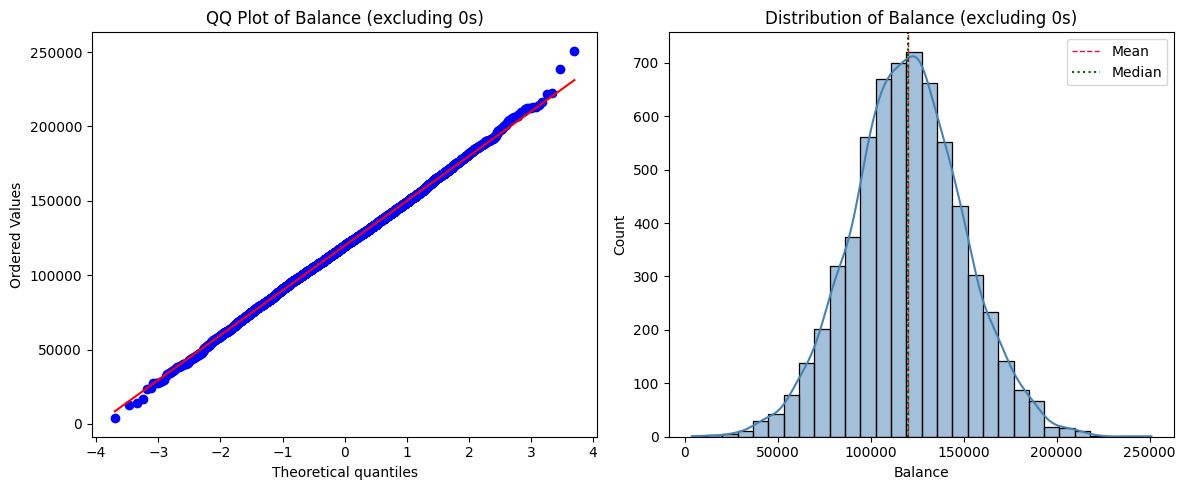

Balance Benford MAD (excluding 0s):
 first digit MAD: 0.11234525474424717
 first two digit MAD: 0.011840998915983371
Round-number heaping rates for 'Balance' (excluding zeros):
Value type          Rate   Count     Chart
-------------------  ------  -------  ----------------------------------------
divisible by     10:  0.11%         7  |                                        |
divisible by    100:  0.02%         1  |                                        |
divisible by  1,000:  0.00%         0  |                                        |
divisible by 10,000:  0.00%         0  |                                        |
divisible by 100,000:  0.00%         0  |                                        |

Trailing-zero summary:
 1 zero:       7 /   6,383 ( 0.11%)
 2 zeros:       1 /   6,383 ( 0.02%)
 3 zeros:       0 /   6,383 ( 0.00%)
 4 zeros:       0 /   6,383 ( 0.00%)
 5 zeros:       0 /   6,383 ( 0.00%)


In [1]:
%run ./eda_demo.ipynb


## Setup
Load the dataset once and define shared column groups used across the rest of the notebook.


In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")
df_model = pd.read_csv(os.path.join(dataset_path, "Churn_Modelling.csv"))

target_col = 'Exited'
id_cols = ['RowNumber', 'CustomerId', 'Surname']
drop_cols = ['RowNumber', 'CustomerId', 'Surname']
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts']
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

print('Dataset path:', dataset_path)
print('Shape:', df_model.shape)
df_model.head()


Dataset path: C:\Users\youpi\.cache\kagglehub\datasets\shrutimechlearn\churn-modelling\versions\1
Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Basic EDA
Start with quick visual and quality checks on the raw dataset.


In [3]:
basic_data_visualization(df_model)


First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Summary statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
mean,5000.5,1.56909e+07,650.529,38.9218,5.0128,76485.9,1.5302,0.7055,0.5151,100090,0.2037
std,2886.9,71936.2,96.6533,10.4878,2.89217,62397.4,0.581654,0.45584,0.499797,57510.5,0.402769
min,1,1.55657e+07,350,18,0,0,1,0,0,11.58,0
25%,2500.75,1.56285e+07,584,32,3,0,1,0,0,51002.1,0
50%,5000.5,1.56907e+07,652,37,5,97198.5,1,1,1,100194,0
75%,7500.25,1.57532e+07,718,44,7,127644,2,1,1,149388,0
max,10000,1.58157e+07,850,92,10,250898,4,1,1,199992,1



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None


Target variable distribution:


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Data quality overview:
Duplicate rows: 0

Missing values per column:
No missing values found.

Negative value check:
No negative values found in numerical columns.

Categorical distributions:


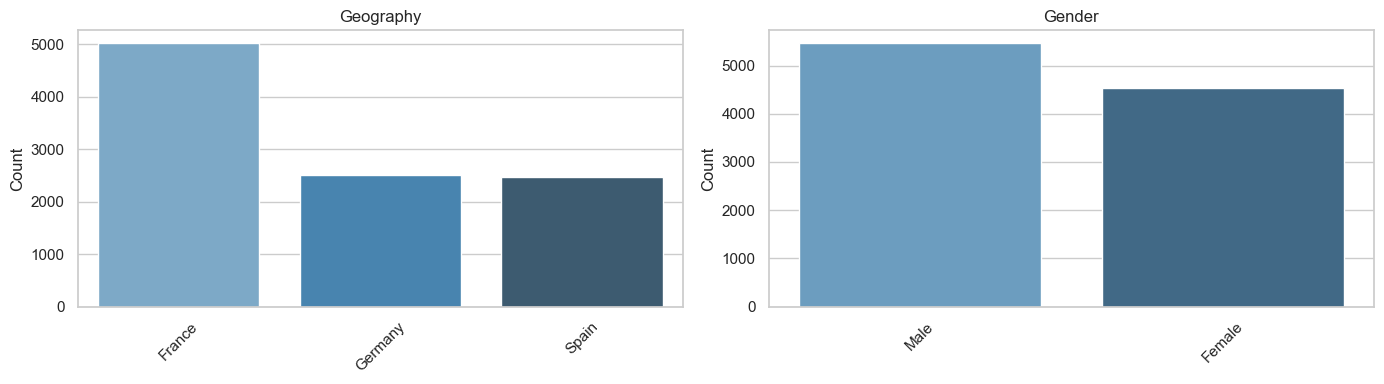


High-cardinality categorical columns (top 15 values):


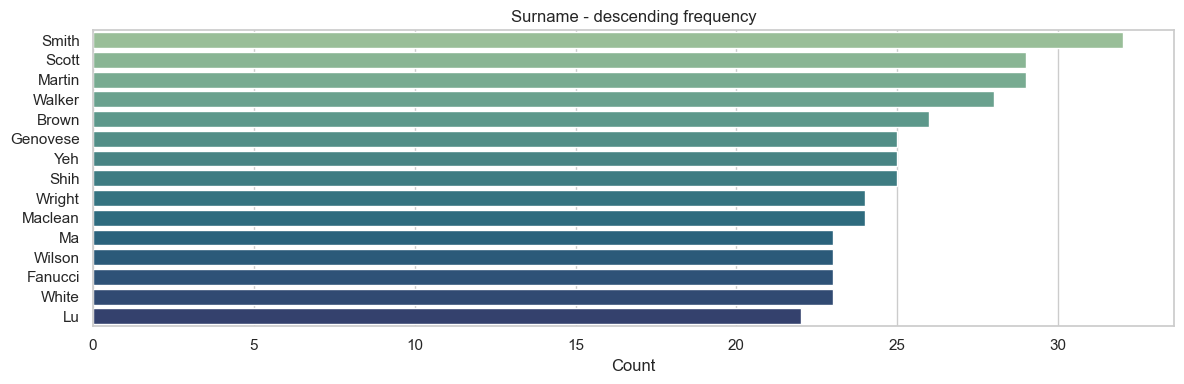


Numerical distributions:


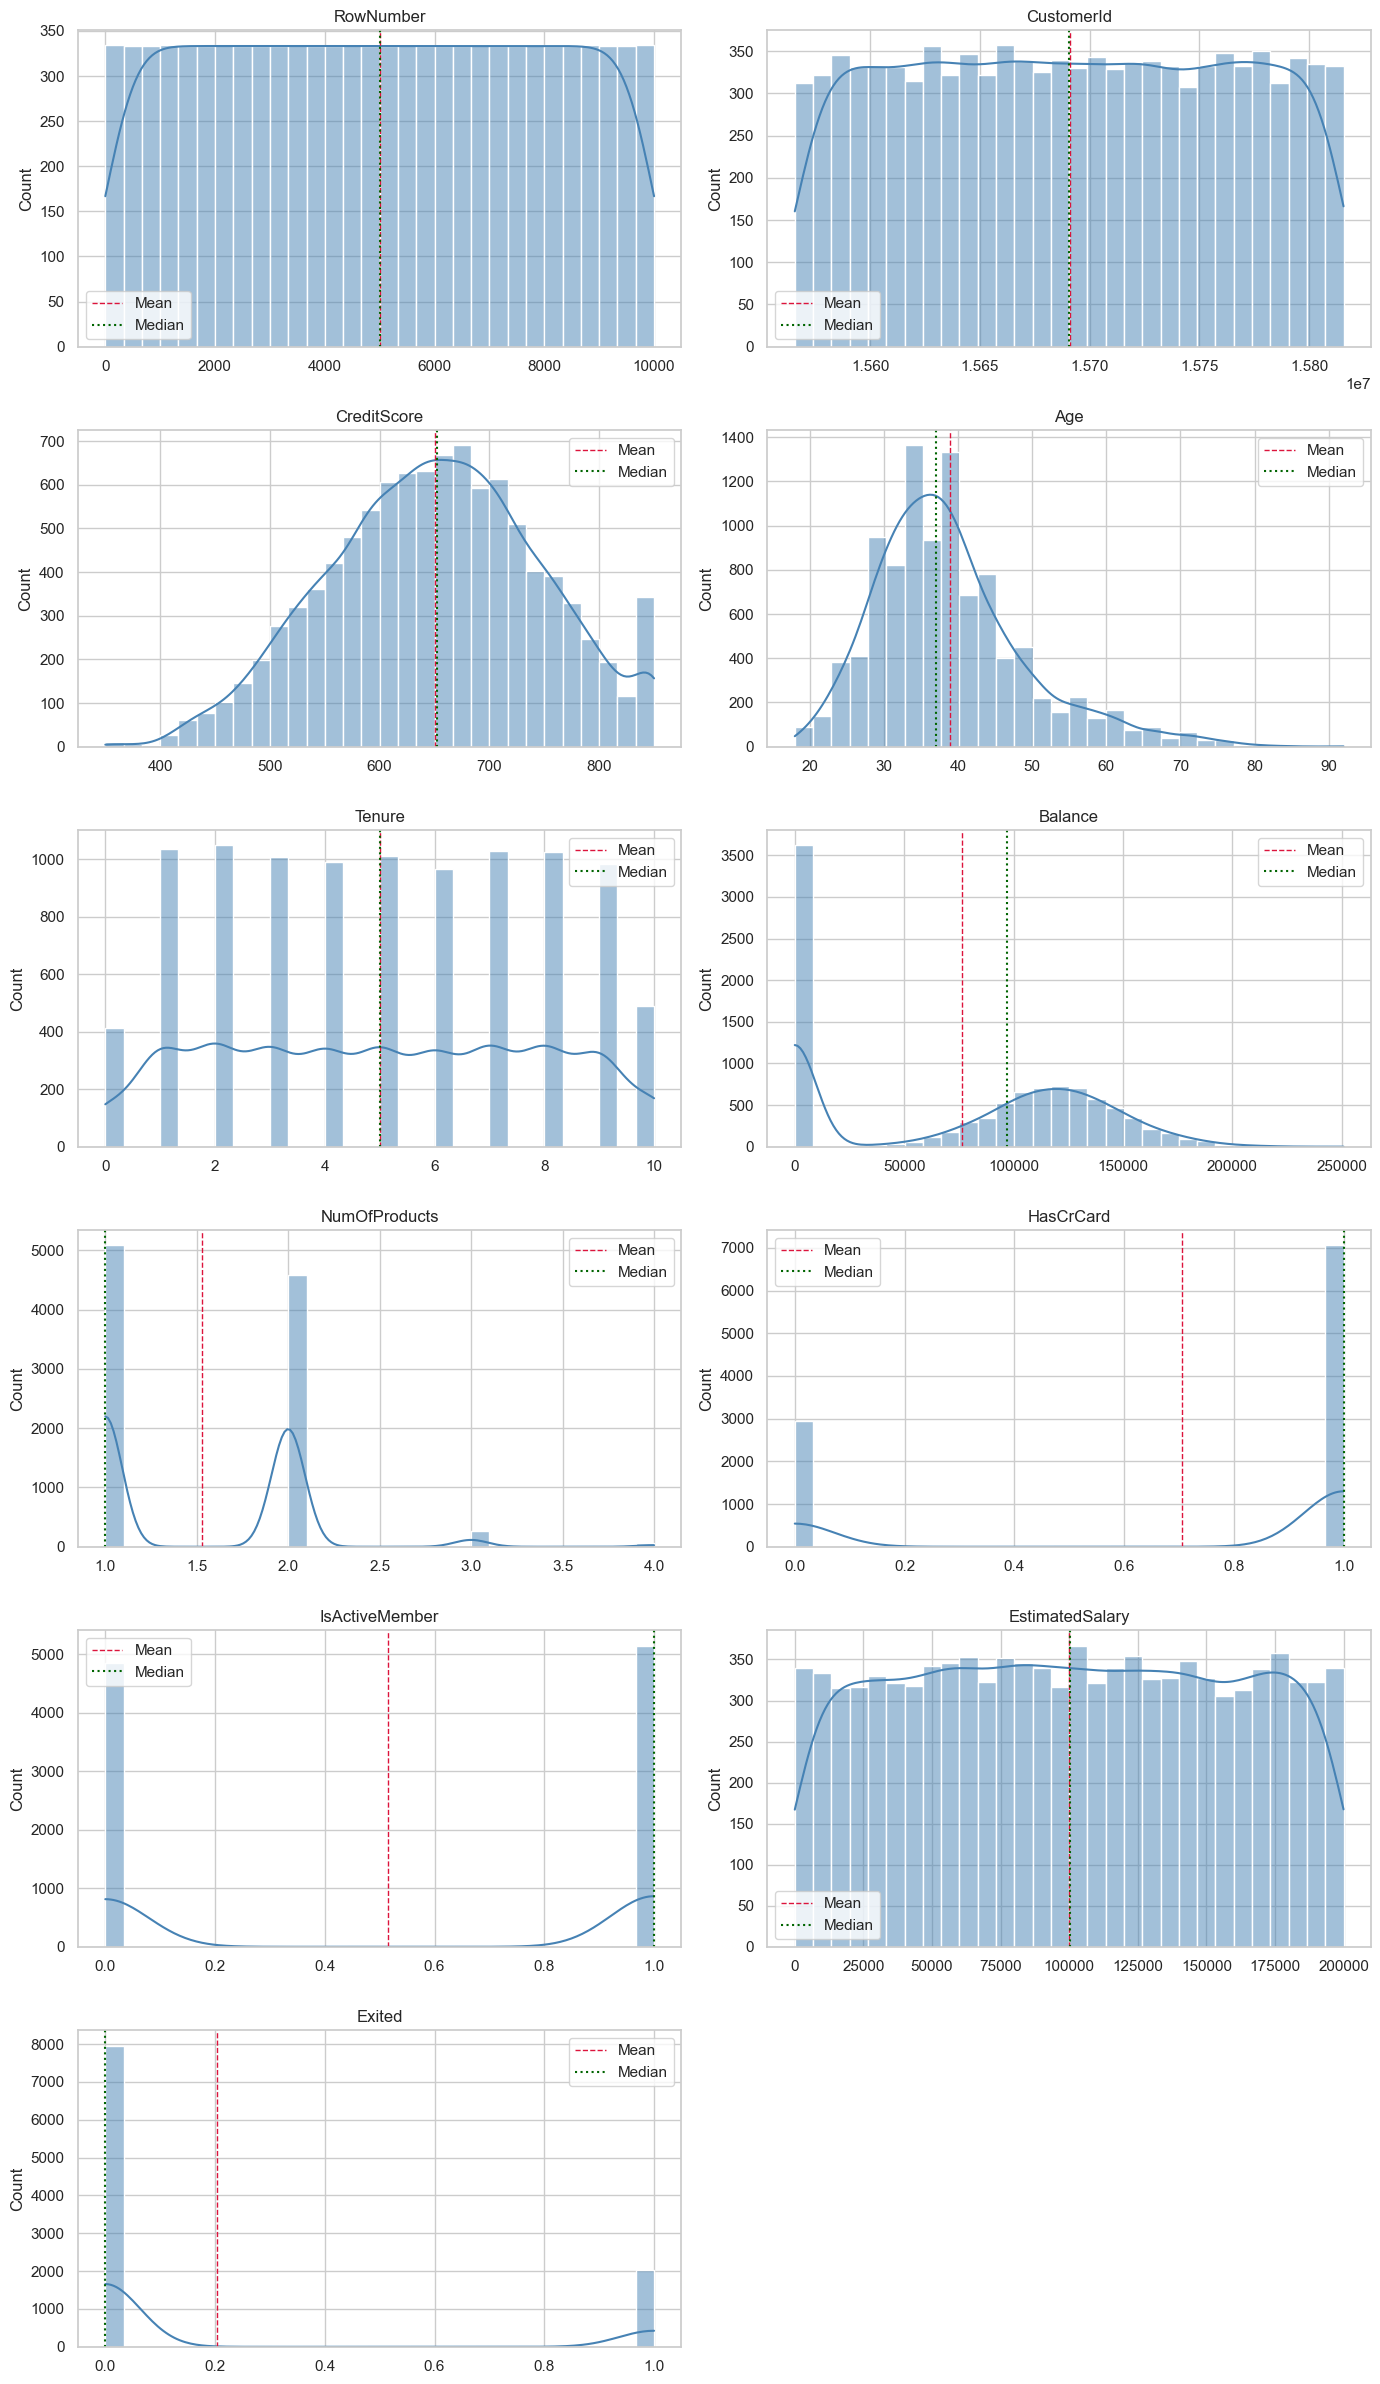

In [4]:
basic_data_quality_checks(df_model)


## Full Audit Summary
Run the broader audit to generate column-level checks, anomaly scores, row-level suspicion signals, and plots.


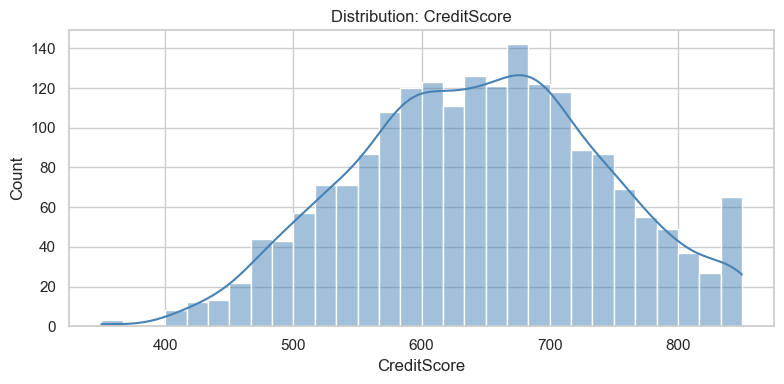

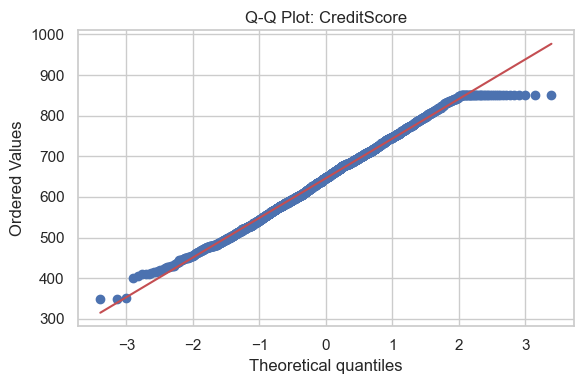

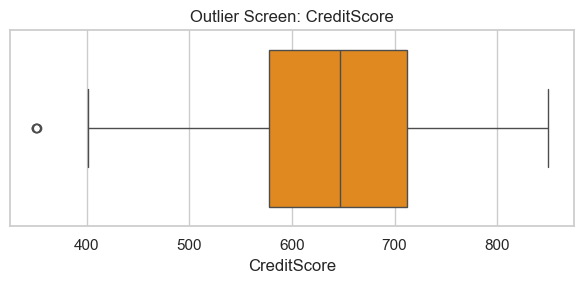

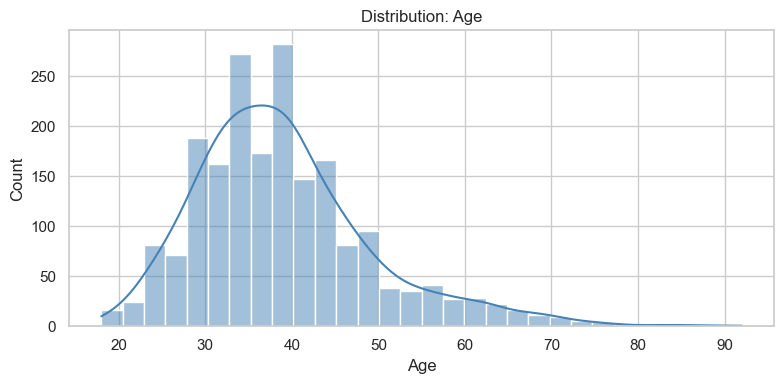

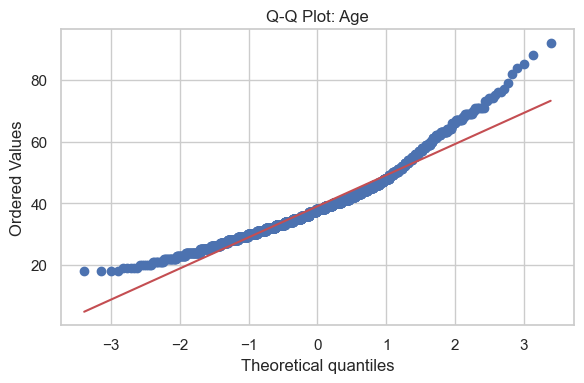

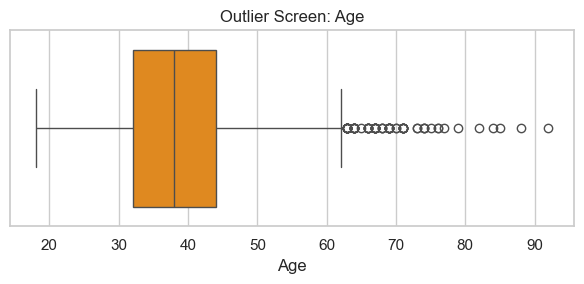

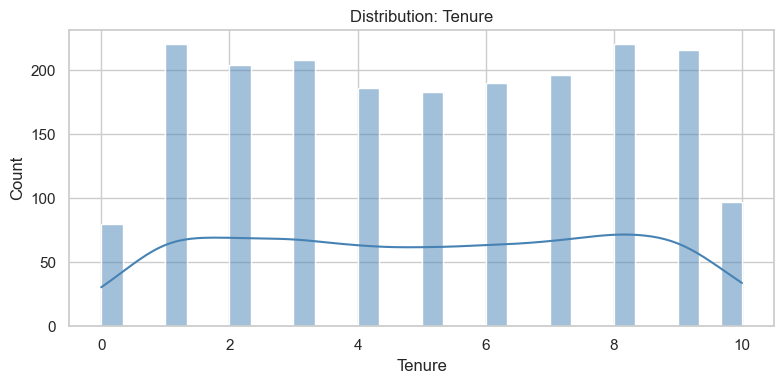

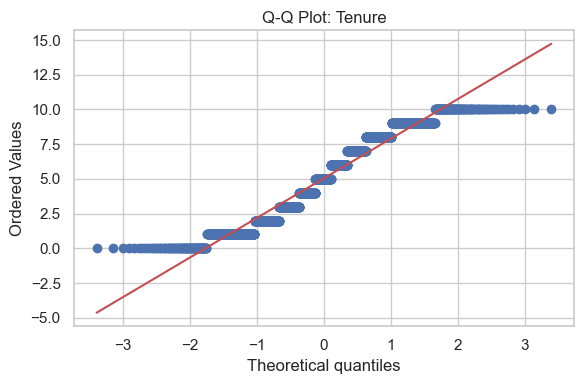

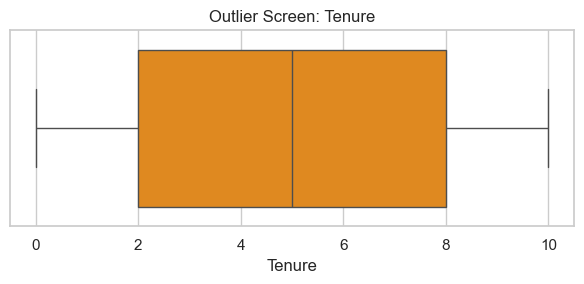

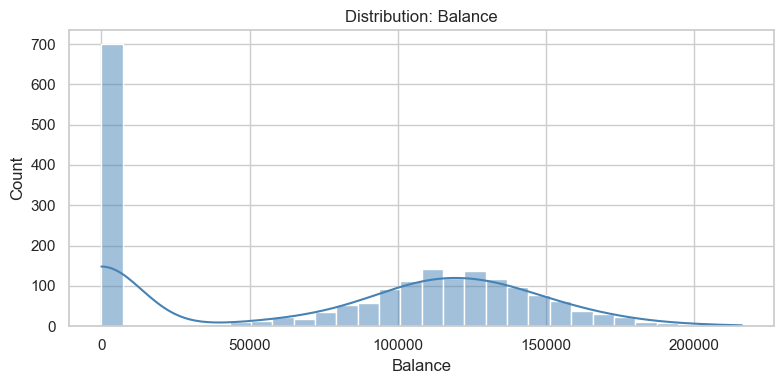

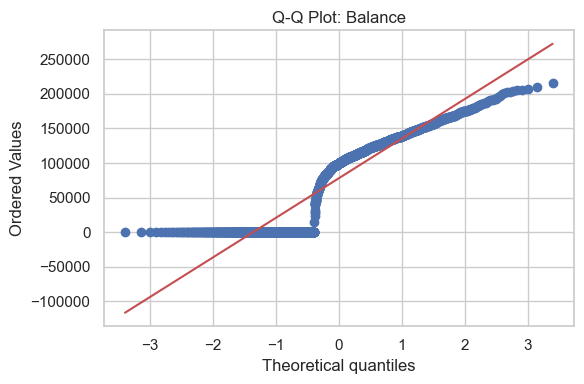

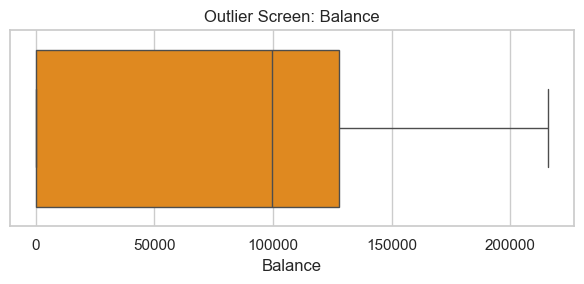

C:\Users\youpi\AppData\Local\Temp\ipykernel_13756\879402150.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="crest")


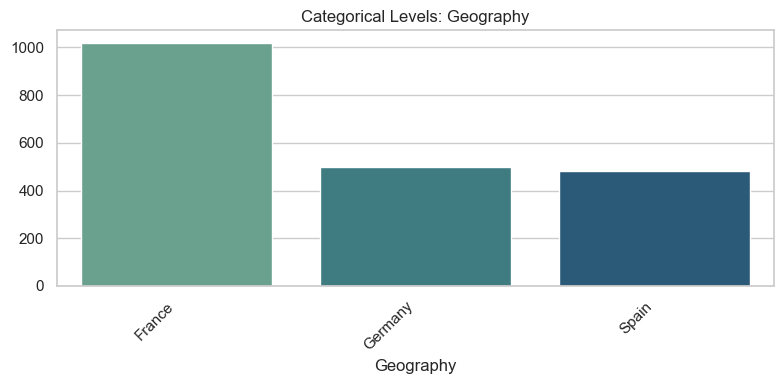

C:\Users\youpi\AppData\Local\Temp\ipykernel_13756\879402150.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="crest")


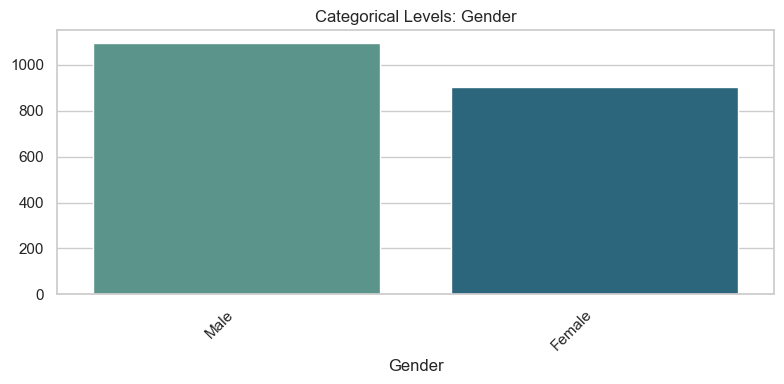

C:\Users\youpi\AppData\Local\Temp\ipykernel_13756\879402150.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="crest")


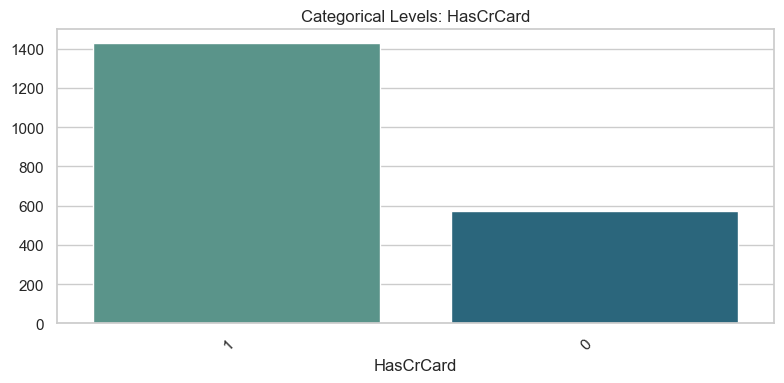

C:\Users\youpi\AppData\Local\Temp\ipykernel_13756\879402150.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="crest")


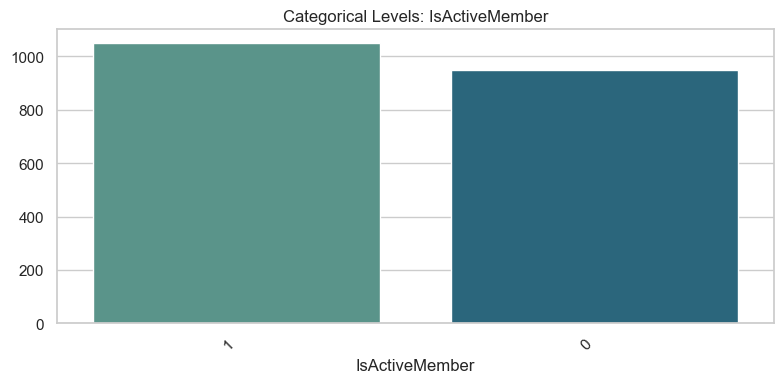

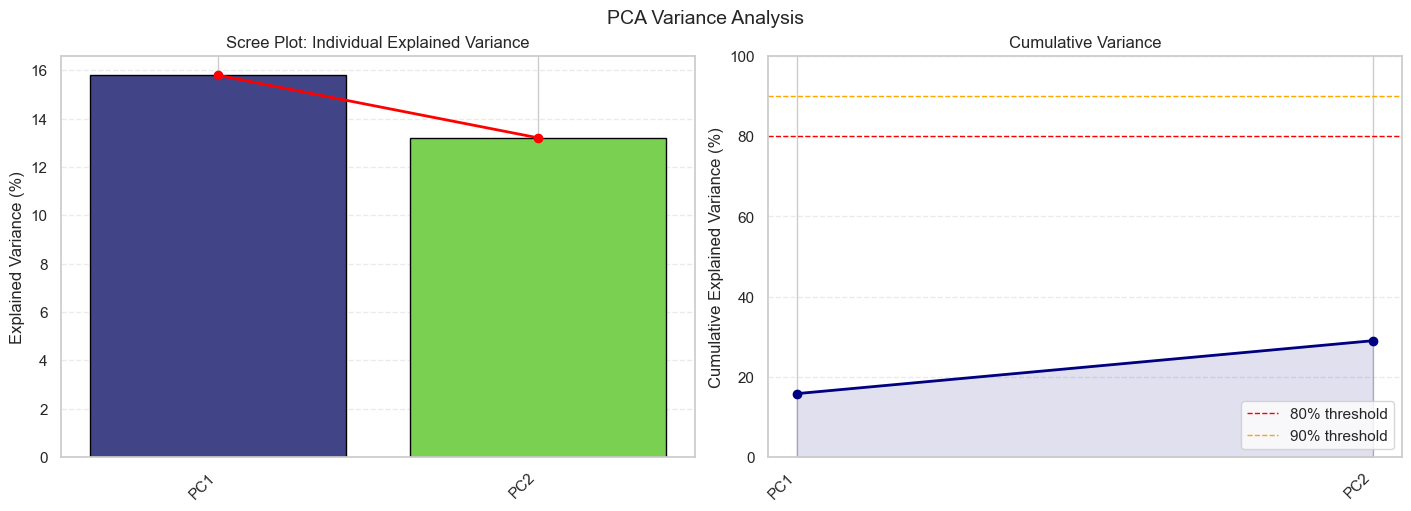

PCA Component Keys (Top Contributing Features):
  PC1: Exited (+0.539), Balance (+0.532), NumOfProducts (-0.481), Age (+0.410), IsActiveMember (-0.139)
  PC2: NumOfProducts (+0.520), Age (+0.515), Exited (+0.482), Balance (-0.455), IsActiveMember (-0.131)


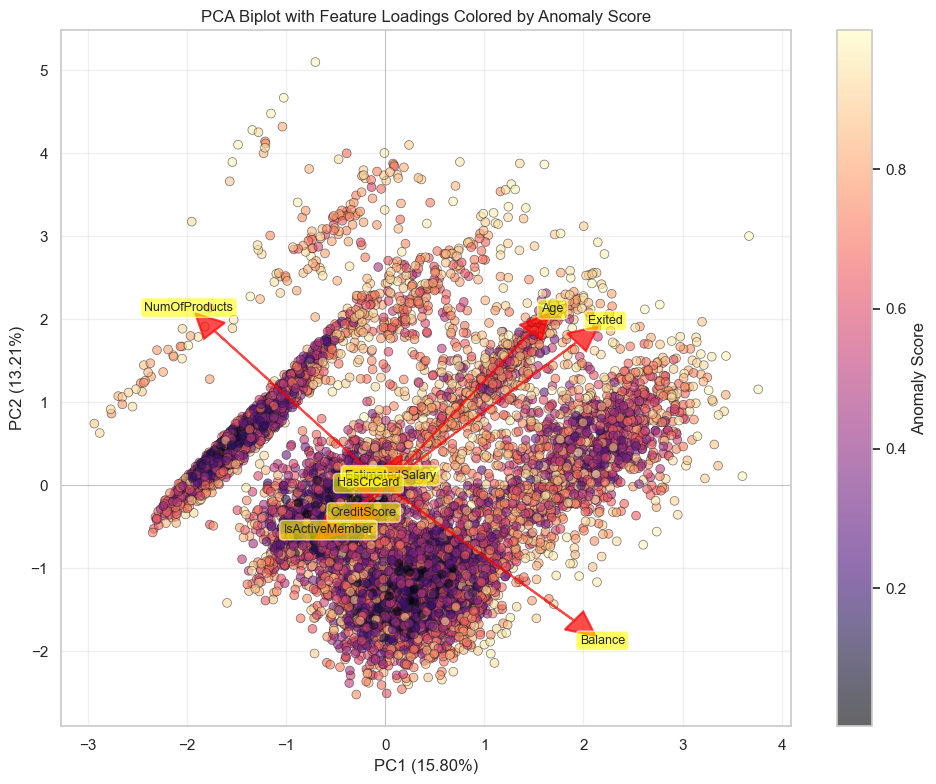

C:\Users\youpi\AppData\Local\Temp\ipykernel_13756\879402150.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=applicable.head(10), x="first_digit_mad", y="column", palette="rocket")


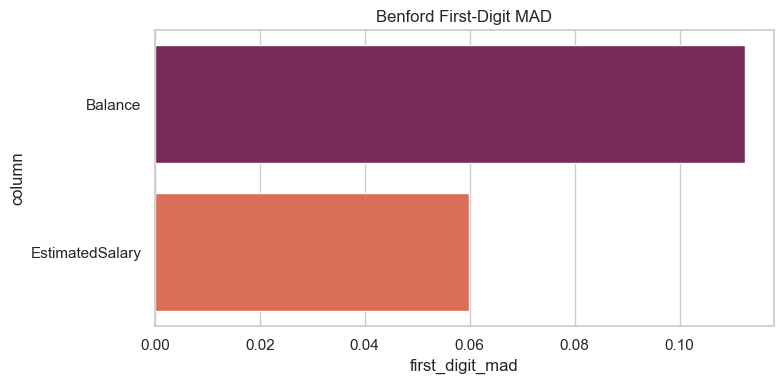

C:\Users\youpi\AppData\Local\Temp\ipykernel_13756\879402150.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=report["digit_preference_checks"].head(10), x="round_number_rate", y="column", palette="flare")


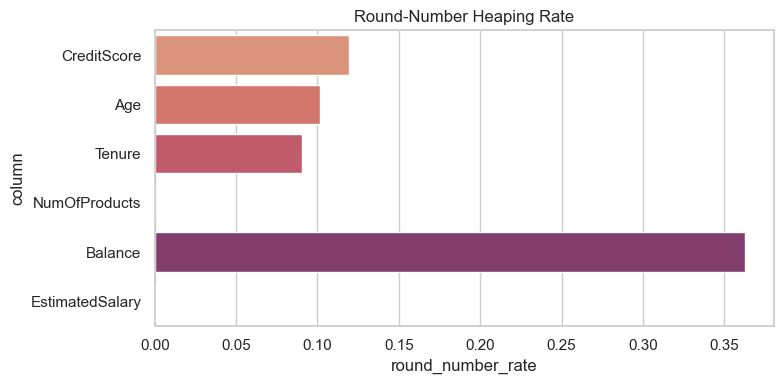

Column classification:


,numeric_cols,categorical_cols,boolean_cols,datetime_cols,identifier_cols,excluded_cols,analysis_numeric_cols,analysis_categorical_cols
0,CreditScore,Geography,HasCrCard,NaN,RowNumber,NaN,CreditScore,Geography
1,Age,Gender,IsActiveMember,NaN,CustomerId,NaN,Age,Gender
2,Tenure,NaN,Exited,NaN,Surname,NaN,Tenure,HasCrCard
3,Balance,NaN,NaN,NaN,NaN,NaN,Balance,IsActiveMember
4,NumOfProducts,NaN,NaN,NaN,NaN,NaN,NumOfProducts,Exited
5,EstimatedSalary,NaN,NaN,NaN,NaN,NaN,EstimatedSalary,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,HasCrCard,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,IsActiveMember,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Exited,NaN



Column-level summary:


,column,dtype,group,missing_pct,nunique,invalid_count,coercion_issue_pct,warnings,warning_count,duplicate_row_count,...,repeated_value_share,warning_y,n_levels,rare_level_count,top_level_share,invalid_label_rate,normalized_entropy,warning,rare_levels_preview,column_suspicion_score
10,Exited,int64,boolean,0.0,2,0,NaN,[],0,0,...,NaN,NaN,2.0,0.0,0.7963,0.0,0.729267,False,[],2.611100
8,HasCrCard,int64,boolean,0.0,2,0,NaN,[],0,0,...,NaN,NaN,2.0,0.0,0.7055,0.0,0.874463,False,[],1.411000
7,Gender,object,categorical,0.0,2,0,0.0,[],0,0,...,NaN,NaN,2.0,0.0,0.5457,0.0,0.993965,False,[],1.091400
9,IsActiveMember,int64,boolean,0.0,2,0,NaN,[],0,0,...,NaN,NaN,2.0,0.0,0.5151,0.0,0.999342,False,[],1.030200
6,Geography,object,categorical,0.0,3,0,0.0,[],0,0,...,NaN,NaN,3.0,0.0,0.5014,0.0,0.945498,False,[],1.002800
1,Age,int64,numeric,0.0,70,0,NaN,[],0,0,...,0.0478,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.539500
4,NumOfProducts,int64,numeric,0.0,4,0,NaN,[],0,0,...,0.5084,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.390000
0,CreditScore,int64,numeric,0.0,460,0,NaN,[],0,0,...,0.0233,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.367500
2,Tenure,int64,numeric,0.0,11,0,NaN,[],0,0,...,0.1048,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.360000
3,Balance,float64,numeric,0.0,6382,0,NaN,[],0,0,...,0.3617,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.354491



Most suspicious rows:


,CreditScore__outlier_votes,Age__outlier_votes,Tenure__outlier_votes,Balance__outlier_votes,NumOfProducts__outlier_votes,EstimatedSalary__outlier_votes,HasCrCard__outlier_votes,IsActiveMember__outlier_votes,Exited__outlier_votes,Geography__rare_level,...,Exited__invalid_label,isolation_forest_score,lof_score,isolation_forest_flag,lof_flag,anomaly_vote_count,combined_anomaly_score,rule_violation_count,suspicious_signal_count,row_suspicion_score
3531,0,3,0,0,0,0,0,0,1,False,...,False,0.657351,1.832344,True,True,2,0.99875,0,6,6.99875
9646,0,3,0,0,0,0,0,0,1,False,...,False,0.623276,1.457710,True,True,2,0.99115,0,6,6.99115
7,1,0,0,0,2,0,0,0,1,False,...,False,0.618781,1.353487,True,True,2,0.98610,0,6,6.9861
1410,0,3,0,0,0,0,0,0,1,False,...,False,0.619824,1.312861,True,True,2,0.98420,0,6,6.9842
5235,0,1,0,0,2,0,0,0,1,False,...,False,0.647994,1.251229,True,True,2,0.98115,0,6,6.98115
2553,0,3,0,0,0,0,0,0,1,False,...,False,0.605722,1.322871,True,True,2,0.97905,0,6,6.97905
3110,0,3,0,0,0,0,0,0,1,False,...,False,0.599544,1.369577,True,True,2,0.97870,0,6,6.9787
7058,0,3,0,0,0,0,0,0,1,False,...,False,0.636642,1.232279,True,True,2,0.97545,0,6,6.97545
9555,0,3,0,0,0,0,0,0,1,False,...,False,0.607166,1.268230,True,True,2,0.97355,0,6,6.97355
3317,0,3,0,0,0,0,0,0,1,False,...,False,0.596379,1.232444,True,True,2,0.96025,0,6,6.96025



Benford applicability notes:


,column,applicable,note,warning
3,Balance,True,Suitable for Benford-style screening.,True
5,EstimatedSalary,True,Suitable for Benford-style screening.,True
0,CreditScore,False,Values do not span enough orders of magnitude ...,False
1,Age,False,Values do not span enough orders of magnitude ...,False
2,Tenure,False,Too few distinct values; repeated or capped am...,False
4,NumOfProducts,False,Values do not span enough orders of magnitude ...,False



Recommendations:
- Benford deviations are warning signals only, not proof of fraud. Review these columns with domain context: Balance, EstimatedSalary
- Digit preference or heaping is elevated for: CreditScore, Age, Tenure, NumOfProducts, Balance
- Multivariate anomaly models flagged 9.1% of rows; inspect the top-ranked records manually.


,column,dtype,group,missing_pct,nunique,invalid_count,coercion_issue_pct,warnings,warning_count,duplicate_row_count,...,repeated_value_share,warning_y,n_levels,rare_level_count,top_level_share,invalid_label_rate,normalized_entropy,warning,rare_levels_preview,column_suspicion_score
10,Exited,int64,boolean,0.0,2,0,NaN,[],0,0,...,NaN,NaN,2.0,0.0,0.7963,0.0,0.729267,False,[],2.611100
8,HasCrCard,int64,boolean,0.0,2,0,NaN,[],0,0,...,NaN,NaN,2.0,0.0,0.7055,0.0,0.874463,False,[],1.411000
7,Gender,object,categorical,0.0,2,0,0.0,[],0,0,...,NaN,NaN,2.0,0.0,0.5457,0.0,0.993965,False,[],1.091400
9,IsActiveMember,int64,boolean,0.0,2,0,NaN,[],0,0,...,NaN,NaN,2.0,0.0,0.5151,0.0,0.999342,False,[],1.030200
6,Geography,object,categorical,0.0,3,0,0.0,[],0,0,...,NaN,NaN,3.0,0.0,0.5014,0.0,0.945498,False,[],1.002800
1,Age,int64,numeric,0.0,70,0,NaN,[],0,0,...,0.0478,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.539500
4,NumOfProducts,int64,numeric,0.0,4,0,NaN,[],0,0,...,0.5084,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.390000
0,CreditScore,int64,numeric,0.0,460,0,NaN,[],0,0,...,0.0233,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.367500
2,Tenure,int64,numeric,0.0,11,0,NaN,[],0,0,...,0.1048,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.360000
3,Balance,float64,numeric,0.0,6382,0,NaN,[],0,0,...,0.3617,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.354491


In [5]:
summary_report = build_summary_report(df=df_model)
summary_report['column_summary'].head(15)


## Anomaly Visuals
Join the audit-produced anomaly signals back onto the raw dataframe so the anomaly views operate on the enriched dataset.


{'loadings':                      PC1       PC2       PC3       PC4       PC5
 CreditScore     0.014406  0.170092 -0.003992  0.955294 -0.109384
 Age            -0.136175  0.598112  0.328124 -0.226921  0.182569
 Tenure          0.065536 -0.286431  0.607406  0.168869  0.699246
 Balance        -0.697949 -0.073262  0.008153  0.069217  0.000775
 NumOfProducts   0.698085  0.082152 -0.034689 -0.007533  0.021688
 HasCrCard       0.049989 -0.215484  0.696615 -0.043270 -0.679815
 IsActiveMember  0.000085  0.687559  0.191926  0.026138 -0.056025,
 'explained_variance': PC1    0.187407
 PC2    0.156922
 PC3    0.144371
 PC4    0.143200
 PC5    0.139711
 Name: explained_variance_ratio, dtype: float64,
 'top_anomalies':       Age    Balance  Exited  NumOfProducts  CreditScore  Tenure Geography  \
 3531   84   87873.39       1              1          408       8    France   
 9292   74  186445.31       0              2          461       1   Germany   
 3497   63  165350.61       1              2     

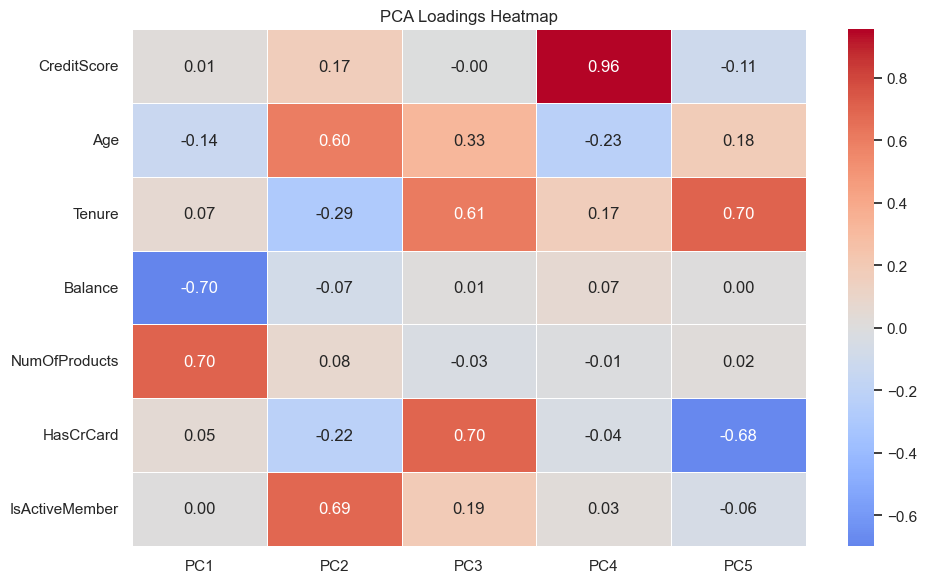

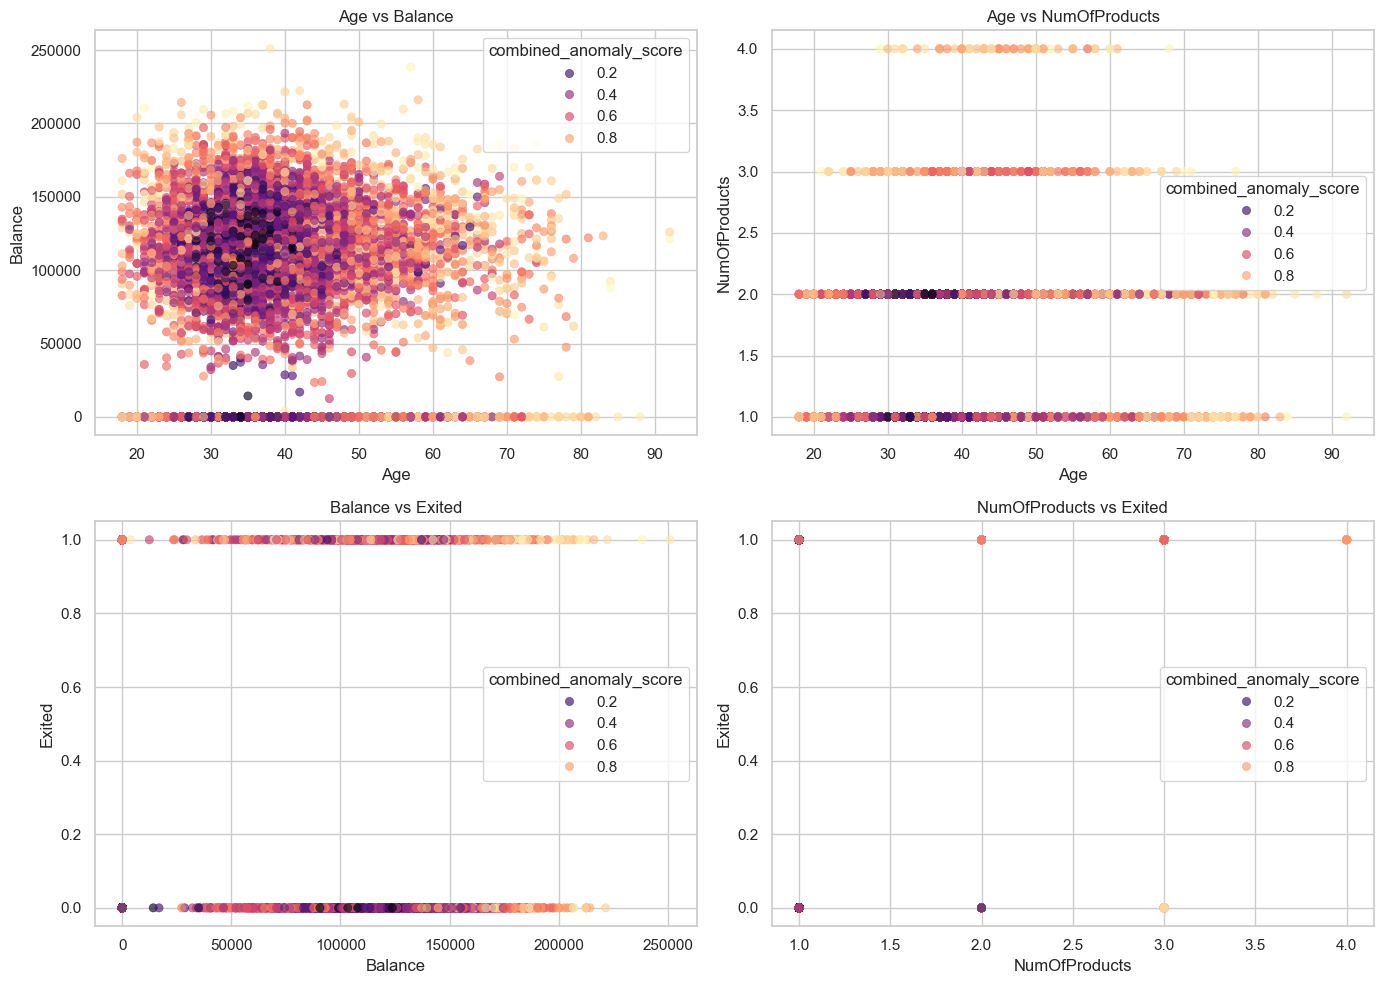

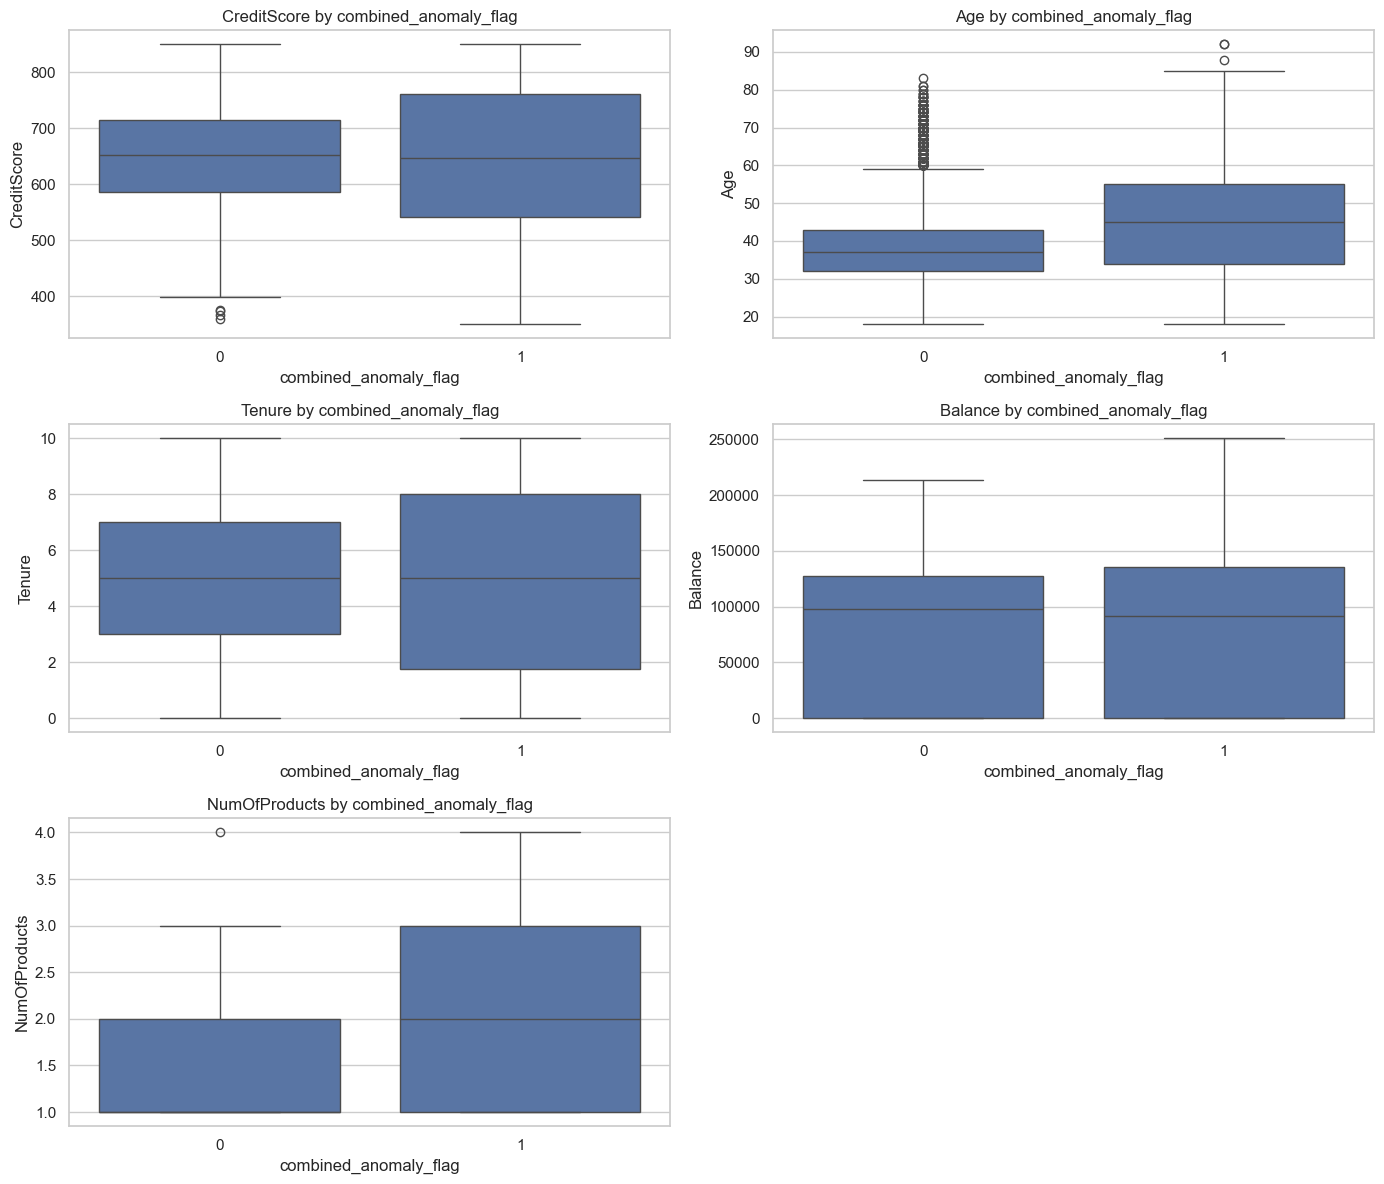

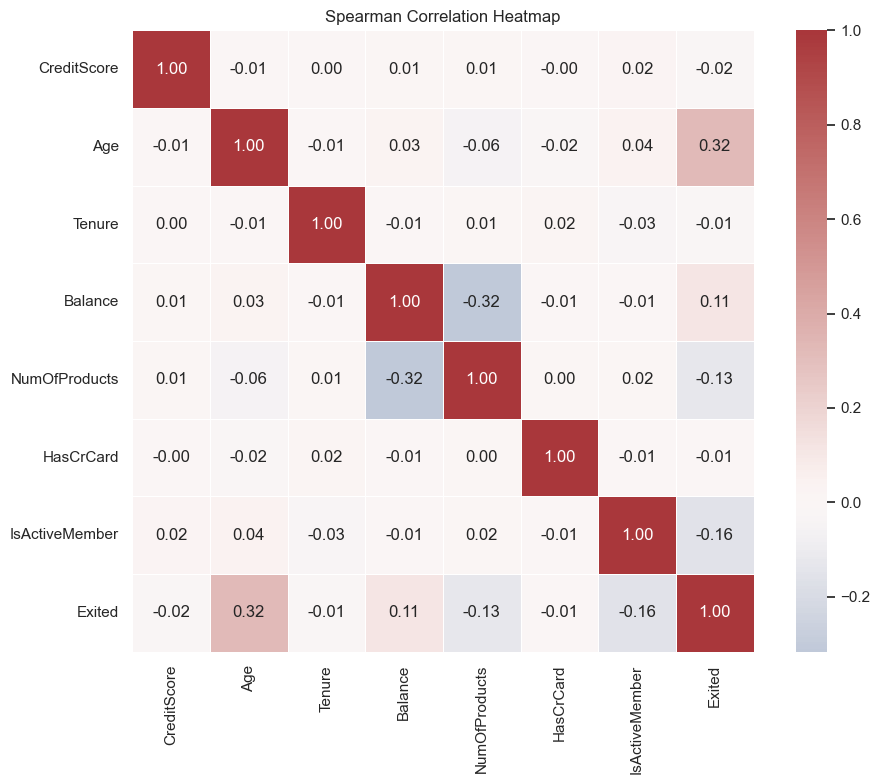

In [6]:
audit_join_cols = [
    col for col in [
        'combined_anomaly_score',
        'row_suspicion_score',
        'anomaly_vote_count',
        'isolation_forest_score',
        'lof_score',
        'isolation_forest_flag',
        'lof_flag',
    ]
    if col in summary_report['row_summary'].columns
]

df_with_audit = df_model.join(summary_report['row_summary'][audit_join_cols], how='left')
if 'combined_anomaly_flag' not in df_with_audit.columns and 'anomaly_vote_count' in df_with_audit.columns:
    df_with_audit['combined_anomaly_flag'] = (df_with_audit['anomaly_vote_count'].fillna(0) > 0).astype(int)

quick_anomaly_viz_bundle(
    df=df_with_audit,
    pca_feature_cols=['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember'],
    corr_cols=['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited'],
    numeric_cols=numeric_cols,
    anomaly_score_col='combined_anomaly_score',
    anomaly_flag_col='combined_anomaly_flag',
    top_n=20,
)


## Leakage Review
Check for identifier-like fields, suspicious target associations, and other prediction-time leakage risks.


In [7]:
leakage_report = run_leakage_audit(
    df_model,
    target_col=target_col,
    id_cols=id_cols,
    datetime_col=None,
    split_col=None,
)

leakage_report['high_risk_candidates']


,column,dtype,missing_pct,nunique,uniqueness_ratio,is_numeric,likely_identifier,keyword_target_like,keyword_future_like,contains_target_name,target_association,association_metric,mutual_information,normalized_entropy,leakage_risk_score,leakage_reasons


## Train, Validation, and Test Splits
Create the split objects once and inspect whether the split composition is sensible.


,split,Exited,n_rows,share
0,test,0,1593,0.796500
1,test,1,407,0.203500
2,train,0,5574,0.796286
3,train,1,1426,0.203714
4,val,0,796,0.796000
5,val,1,204,0.204000


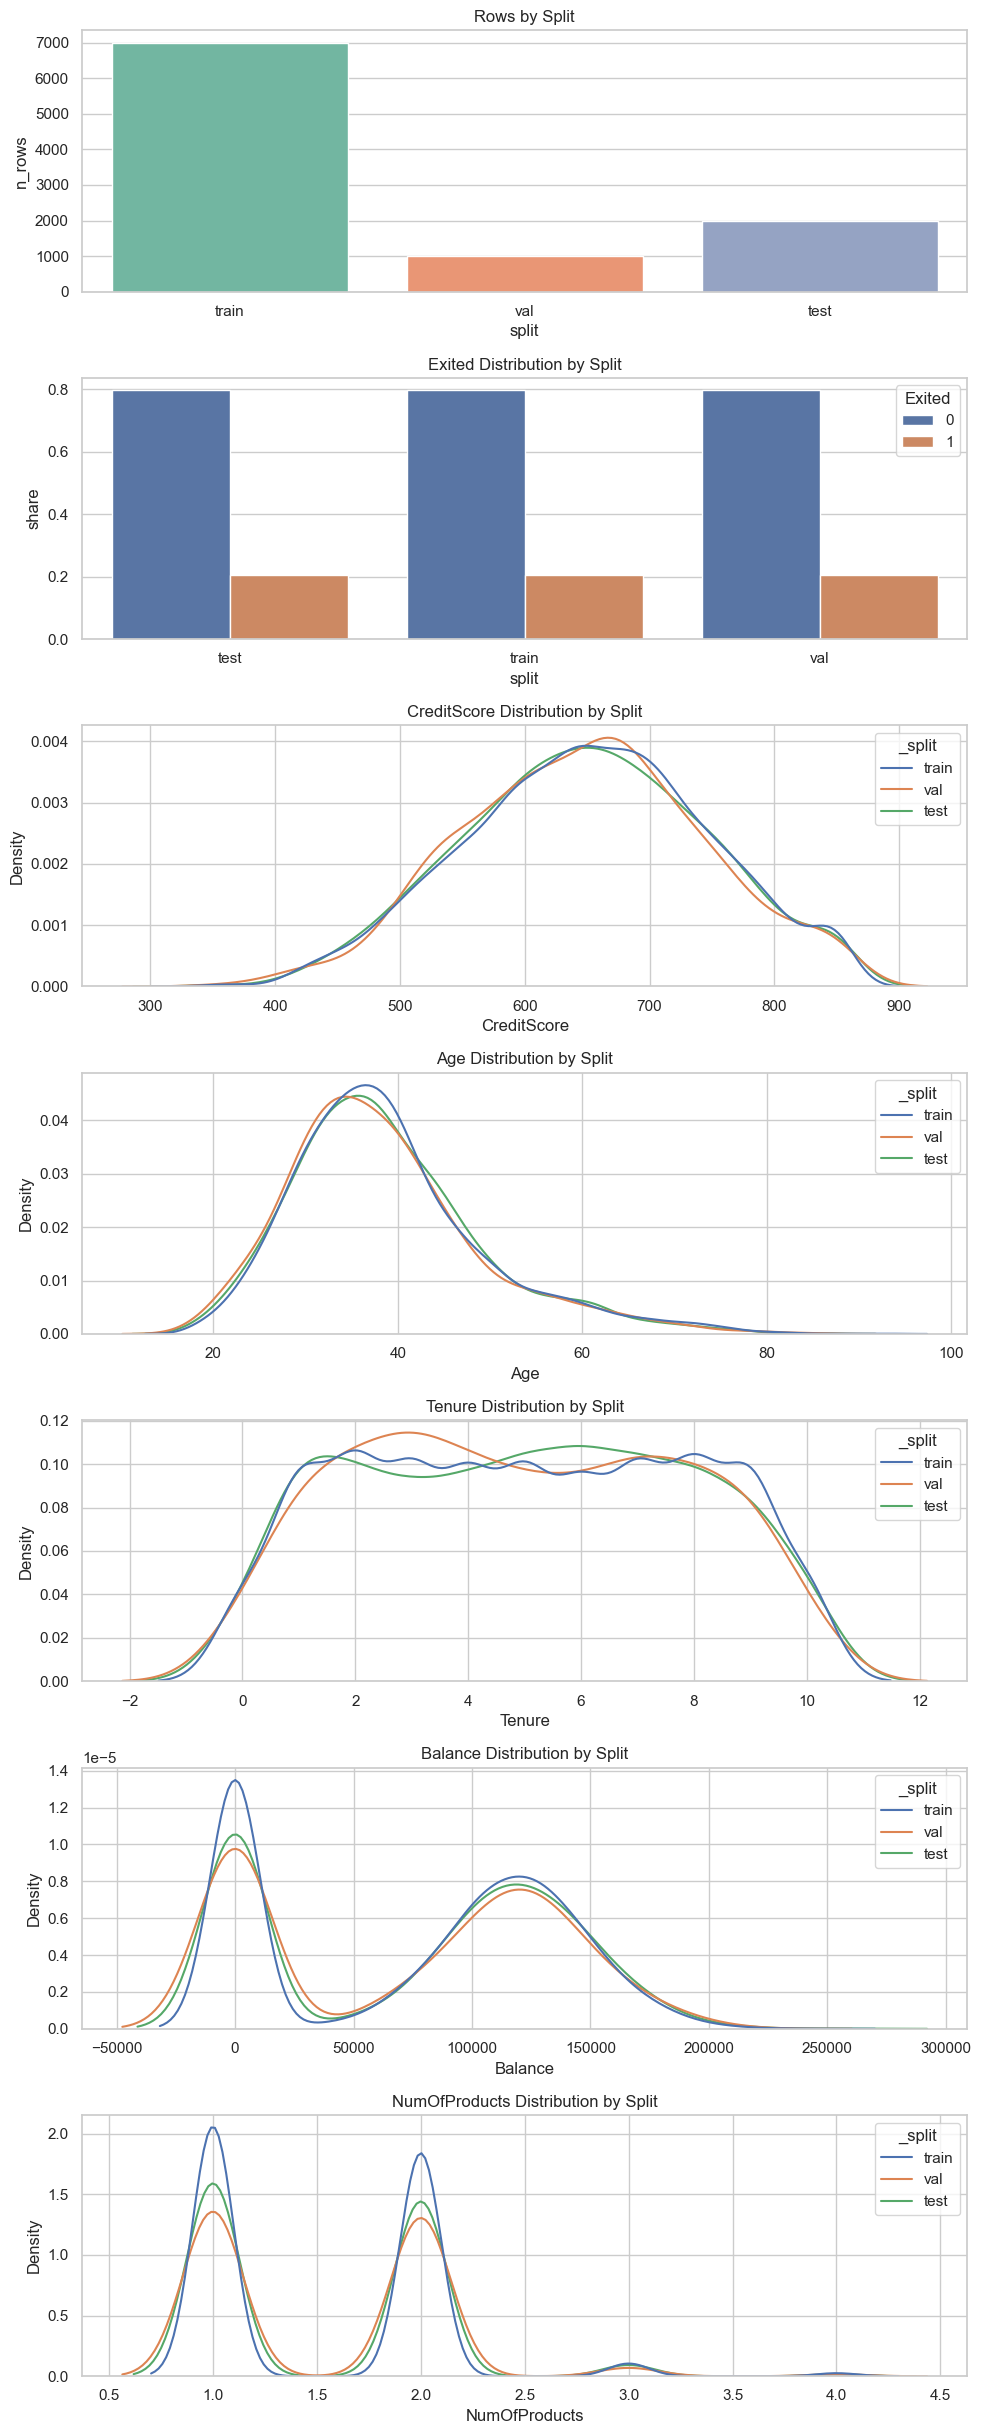

In [8]:
splits = split(
    df_model,
    target_col=target_col,
    test_size=0.2,
    val_size=0.1,
    random_state=42,
    stratify=True,
    drop_cols=drop_cols,
)

split_summary = summarize_splits(
    splits,
    target_col=target_col,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    max_numeric=5,
    top_k_categories=10,
    show_plots=True,
)

split_summary['target_summary']


## Drift and Stability Checks
Compare train and test distributions to see whether the split is stable enough for downstream modeling.


{'headline': 'train vs test: 0 major-shift and 0 moderate-shift features detected.',
 'top_drift_features': [{'column': 'Tenure',
   'dtype_group': 'numeric',
   'psi': 0.00712384048310524,
   'psi_severity': 'stable'},
  {'column': 'Age',
   'dtype_group': 'numeric',
   'psi': 0.005803548970535702,
   'psi_severity': 'stable'},
  {'column': 'CreditScore',
   'dtype_group': 'numeric',
   'psi': 0.001979994269583826,
   'psi_severity': 'stable'},
  {'column': 'Balance',
   'dtype_group': 'numeric',
   'psi': 0.0018048942001915955,
   'psi_severity': 'stable'},
  {'column': 'HasCrCard',
   'dtype_group': 'categorical',
   'psi': 0.0016612264564931506,
   'psi_severity': 'stable'},
  {'column': 'Gender',
   'dtype_group': 'categorical',
   'psi': 0.0009066203123025173,
   'psi_severity': 'stable'},
  {'column': 'Geography',
   'dtype_group': 'categorical',
   'psi': 0.0007955996656720756,
   'psi_severity': 'stable'},
  {'column': 'NumOfProducts',
   'dtype_group': 'numeric',
   'psi': 8.

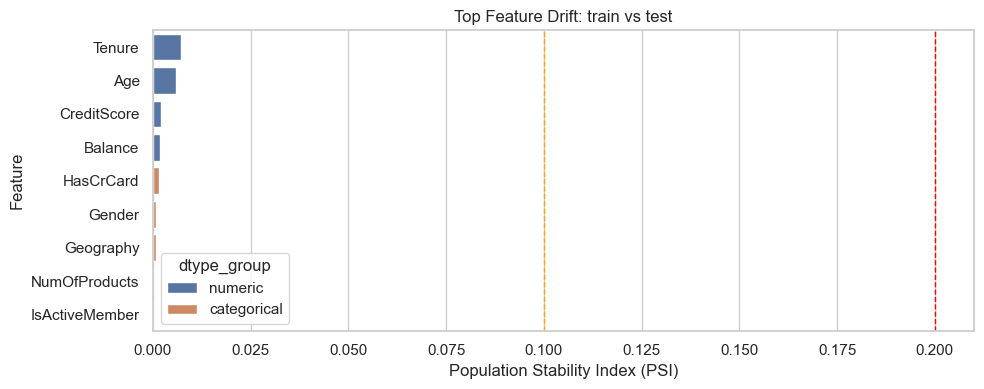

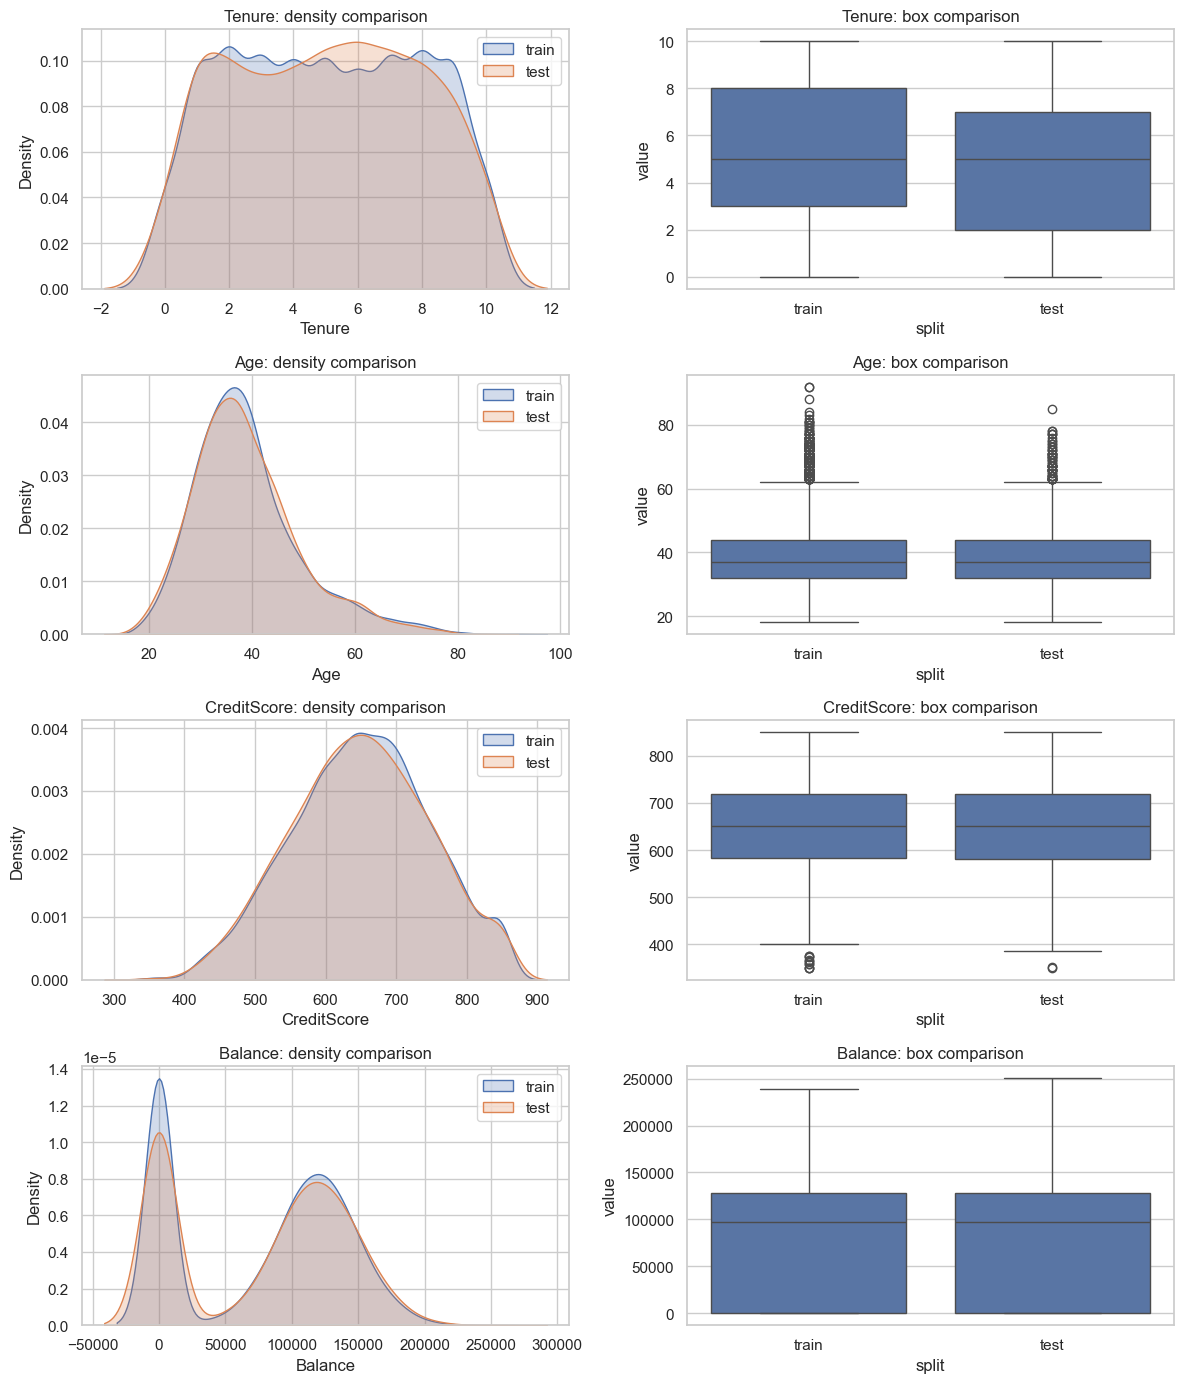

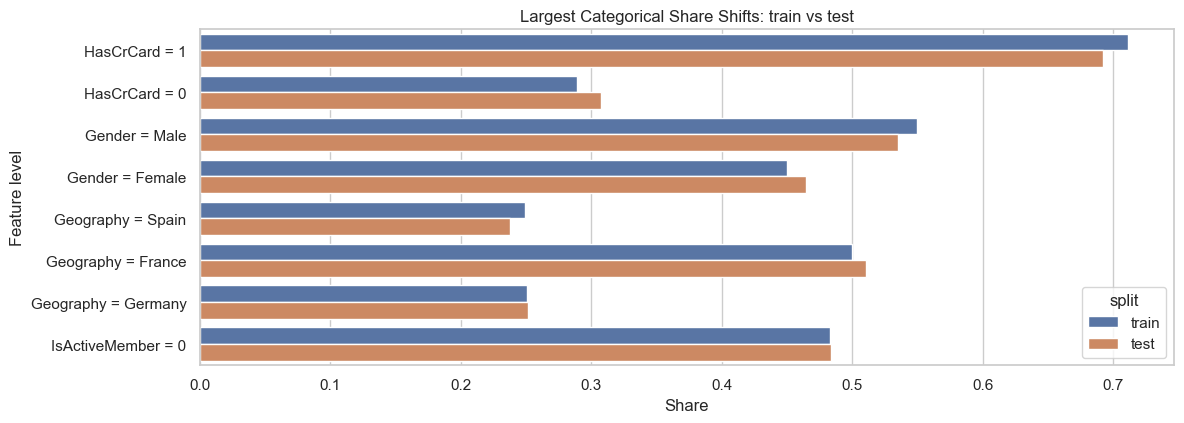

In [9]:
drift_report = run_drift_stability_checks(
    splits,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    boolean_cols=[],
    target_col=target_col,
    base_split='train',
    compare_split='test',
    include_plots=True,
    top_n_levels=5,
    bins=10,
)

summarize_drift_findings(drift_report)


## Segment and Subgroup Analysis
Run the descriptive segmentation views in the same notebook so churn concentration, anomaly concentration, interactions, and subgroup relationship stability are all reviewed here.


COMPREHENSIVE SUBGROUP ANALYSIS

1. TARGET RATE BY SUBGROUPS
----------------------------------------

Gender:


C:\Users\youpi\AppData\Local\Temp\ipykernel_13756\3477880675.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby(col, dropna=False)


,segment,count,positive_count,target_rate,support_share,support_flag,rate_vs_overall,rate_ratio
0,Female,4543,1139,0.250715,0.4543,True,0.047015,1.230807
1,Male,5457,898,0.164559,0.5457,True,-0.039141,0.807851



Geography:


,segment,count,positive_count,target_rate,support_share,support_flag,rate_vs_overall,rate_ratio
0,Germany,2509,814,0.324432,0.2509,True,0.120732,1.592695
1,Spain,2477,413,0.166734,0.2477,True,-0.036966,0.818527
2,France,5014,810,0.161548,0.5014,True,-0.042152,0.793067


...


HasCrCard:


,segment,count,anomaly_count,anomaly_rate,support_share,support_flag,rate_vs_overall,rate_ratio
0,0,2945,429,0.145671,0.2945,True,0.054471,1.597266
1,1,7055,483,0.068462,0.7055,True,-0.022738,0.750681



Age_Band:


,segment,count,anomaly_count,anomaly_rate,support_share,support_flag,rate_vs_overall,rate_ratio
0,65-99,264,77,0.291667,0.0264,True,0.200467,3.198099
1,55-64,536,145,0.270522,0.0536,True,0.179322,2.966254
2,0-24,611,113,0.184943,0.0611,True,0.093743,2.027881
3,45-54,1311,229,0.174676,0.1311,True,0.083476,1.915305
4,35-44,3736,205,0.054872,0.3736,True,-0.036328,0.601661
5,25-34,3542,143,0.040373,0.3542,True,-0.050827,0.442683



3. DISTRIBUTION VISUALIZATIONS
----------------------------------------


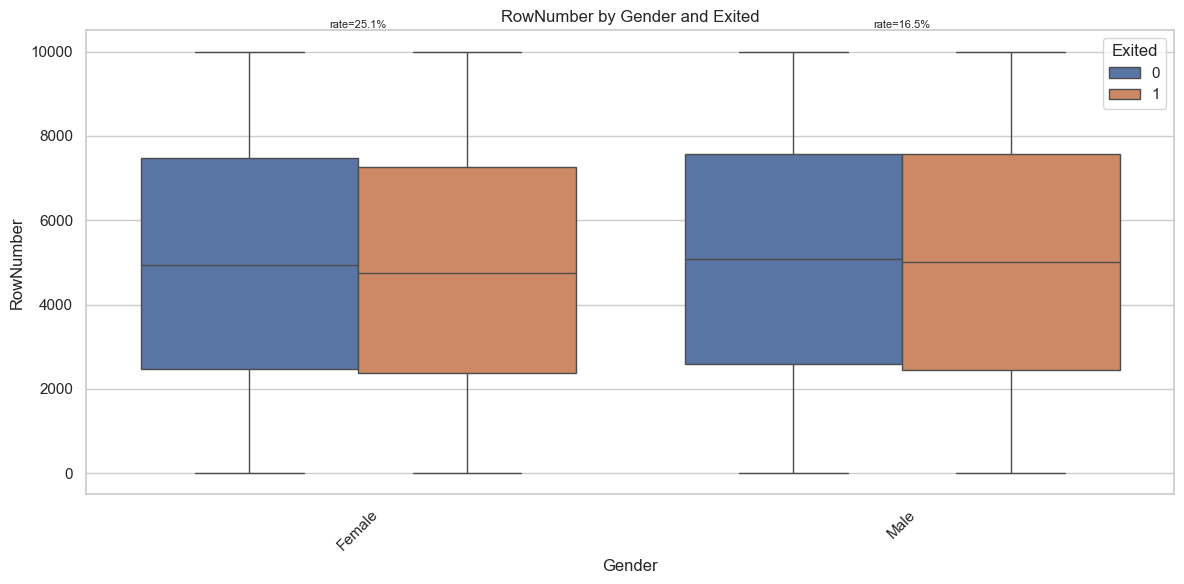

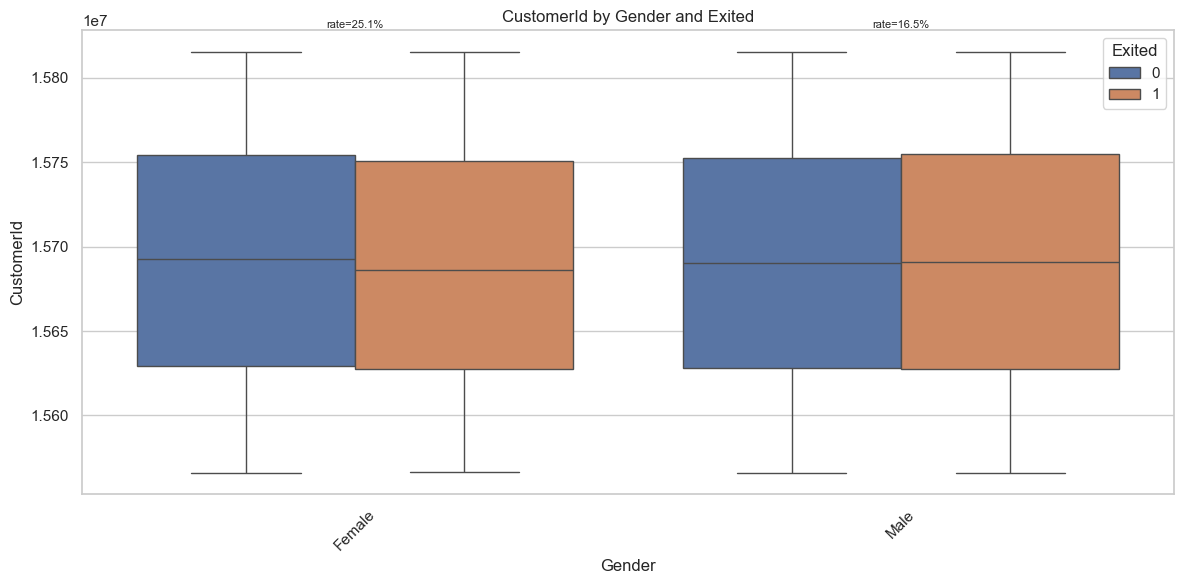

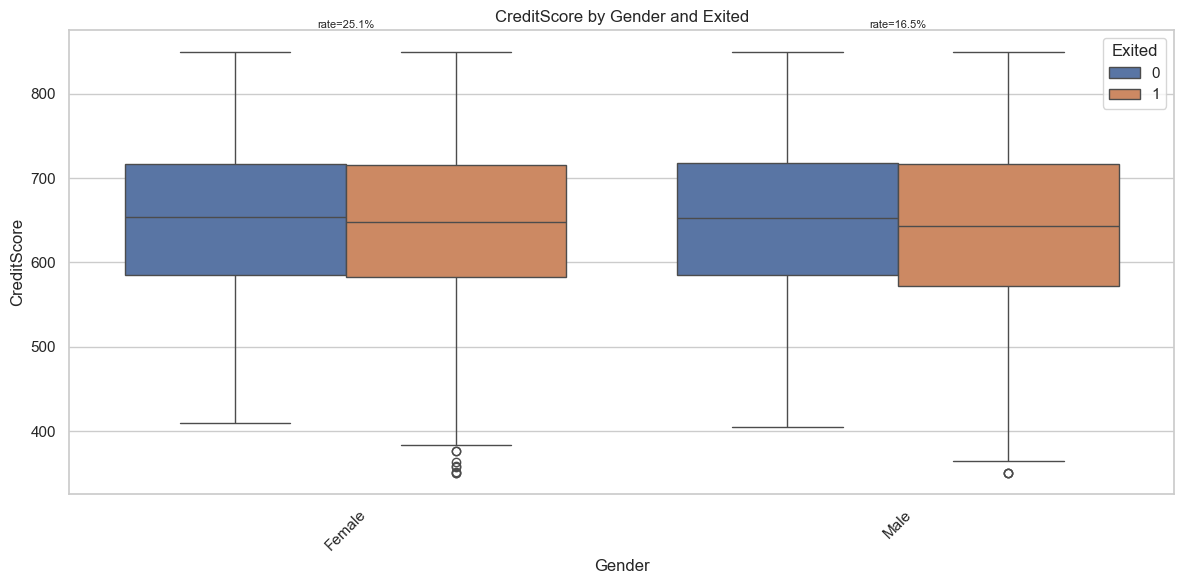

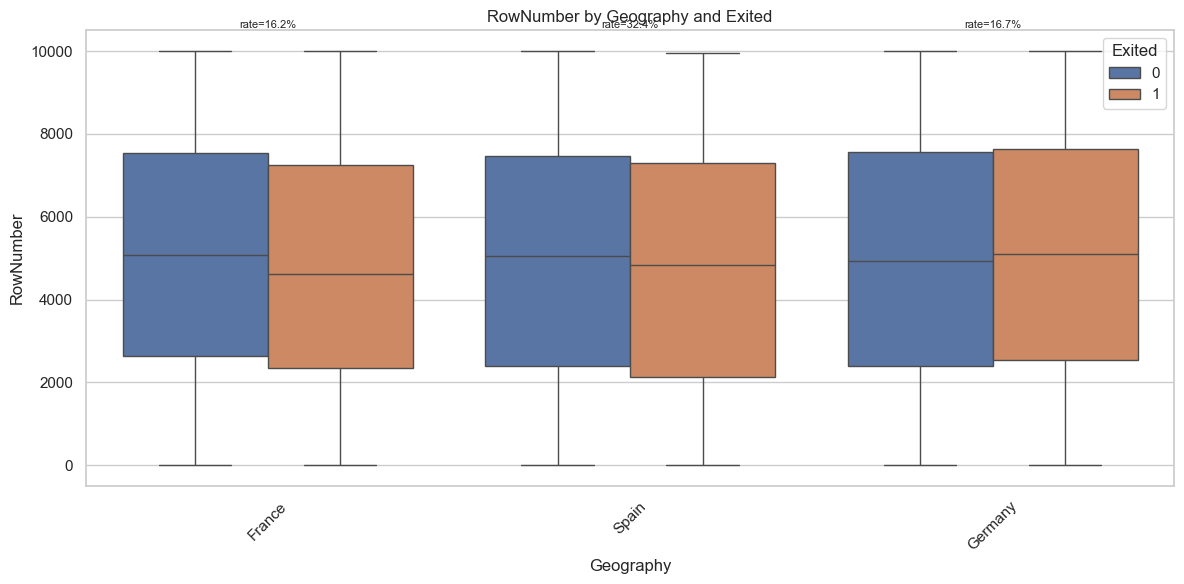

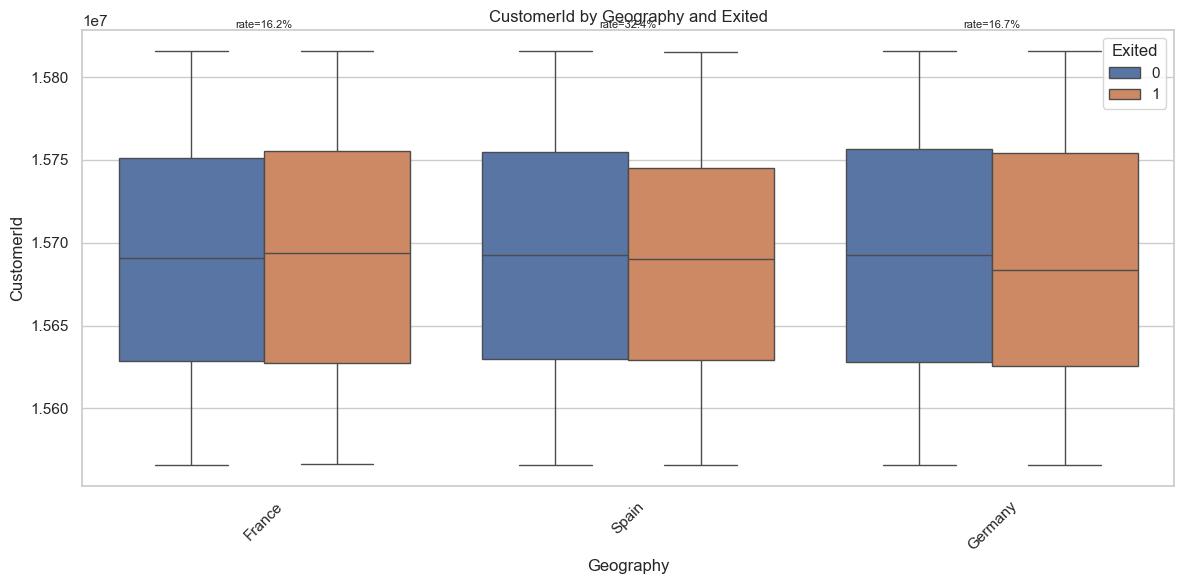

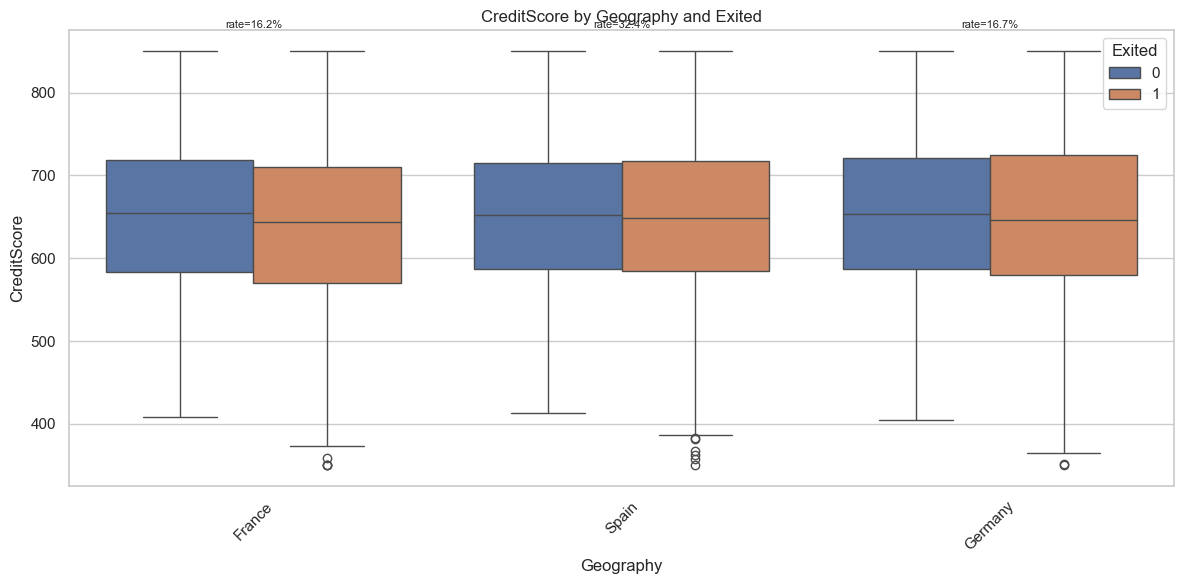

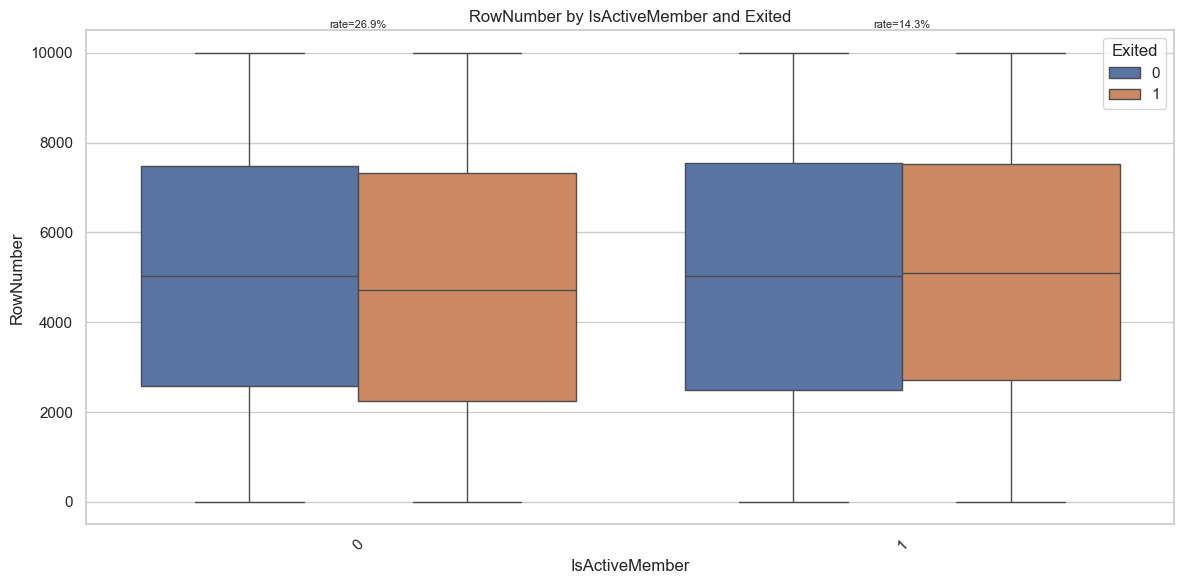

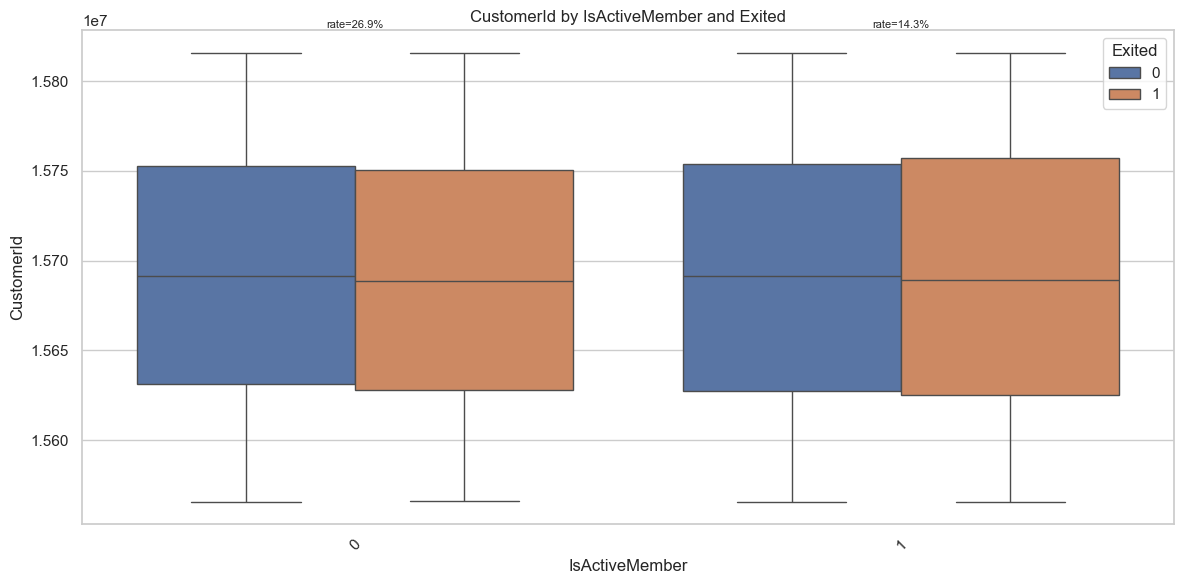


4. INTERACTION ANALYSIS
----------------------------------------

Geography x Gender target interaction:


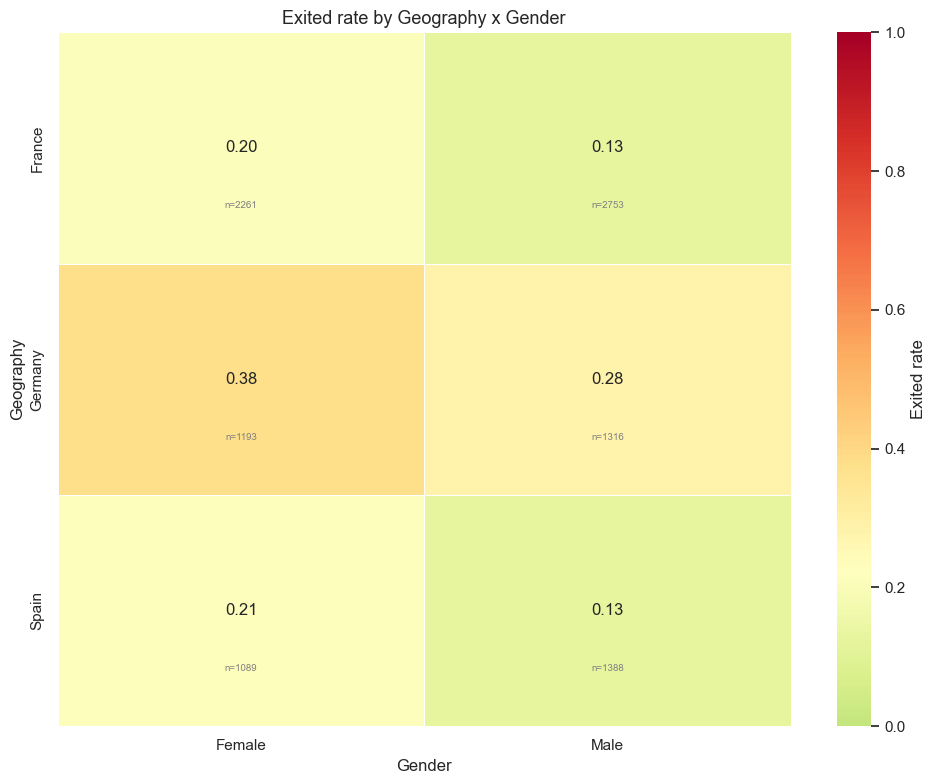


Geography x IsActiveMember target interaction:


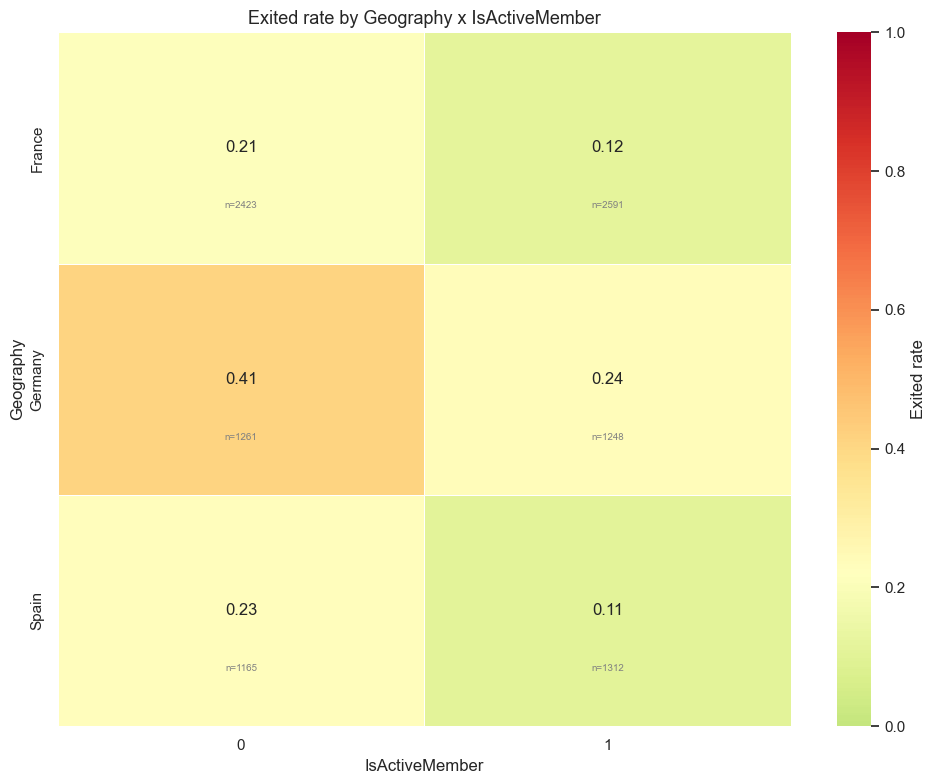


Geography x HasCrCard target interaction:


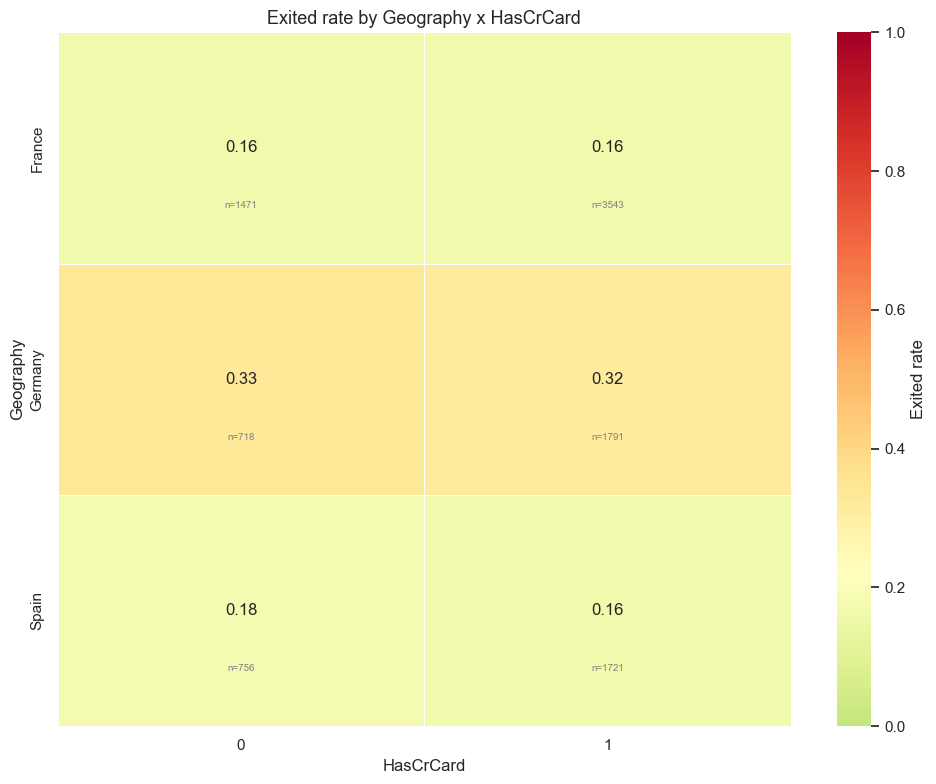


Gender x IsActiveMember target interaction:


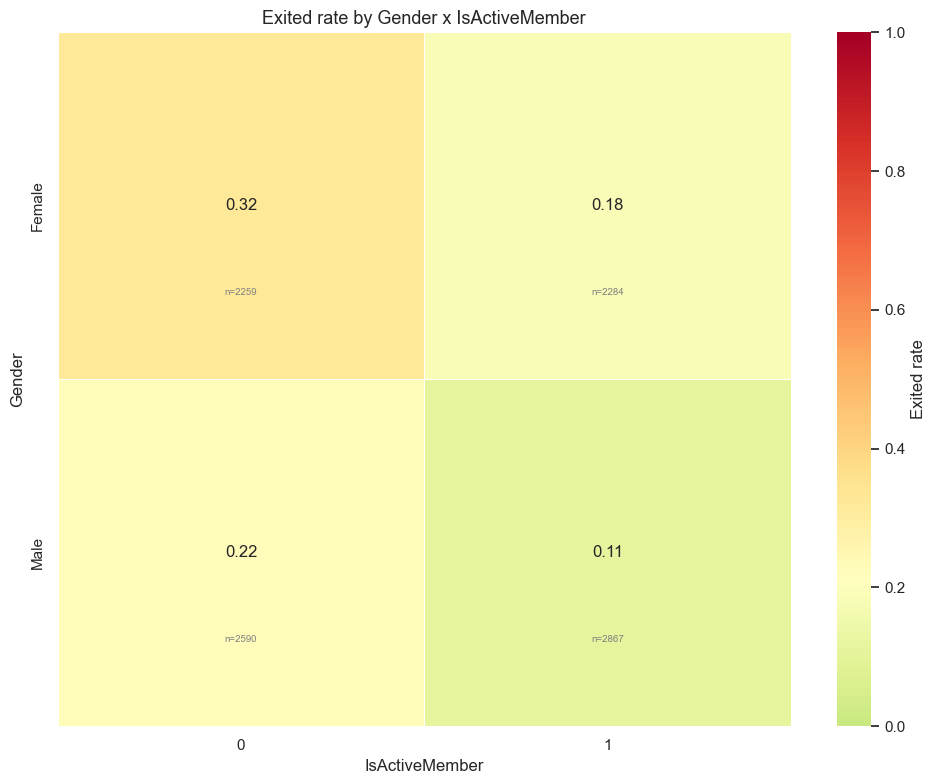


Gender x HasCrCard target interaction:


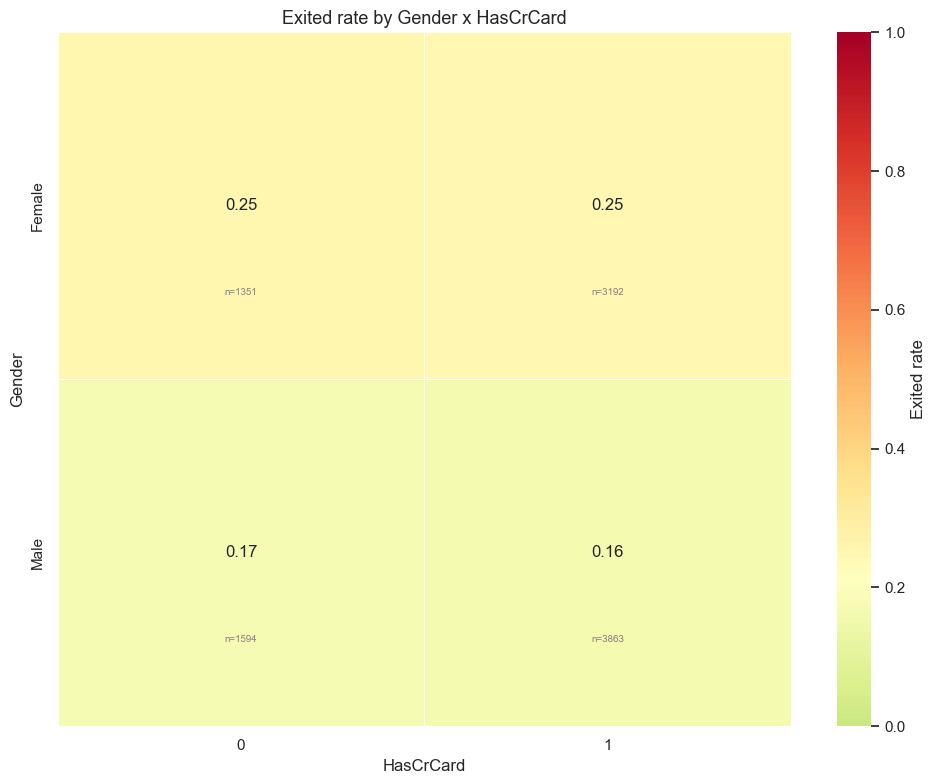


Age_Band x Gender target interaction:


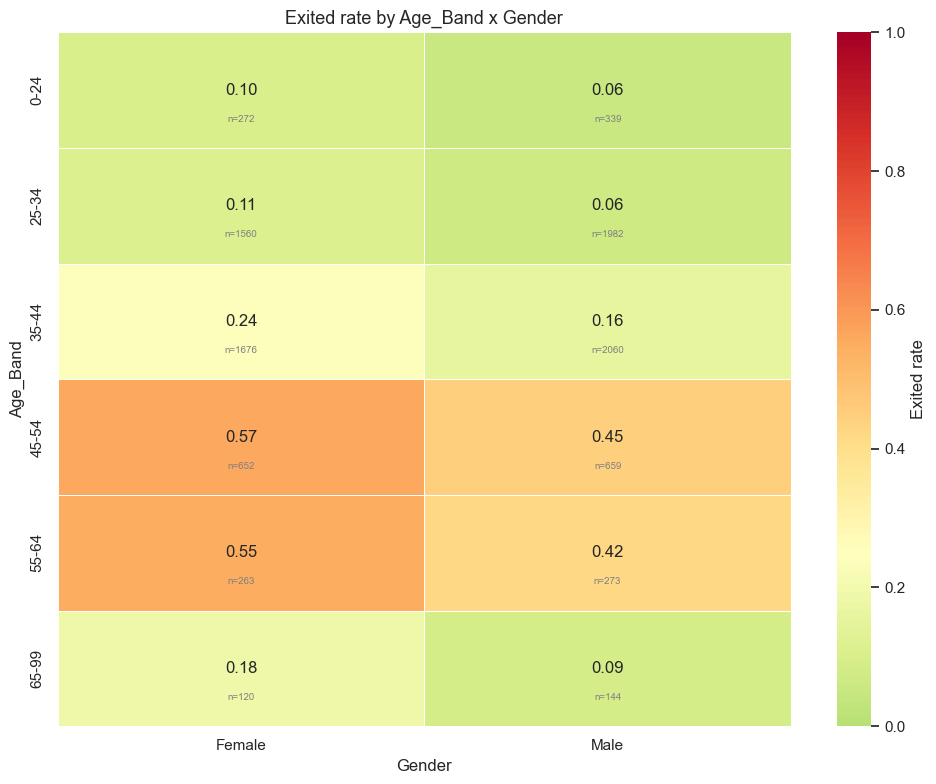


Geography x Gender anomaly interaction:


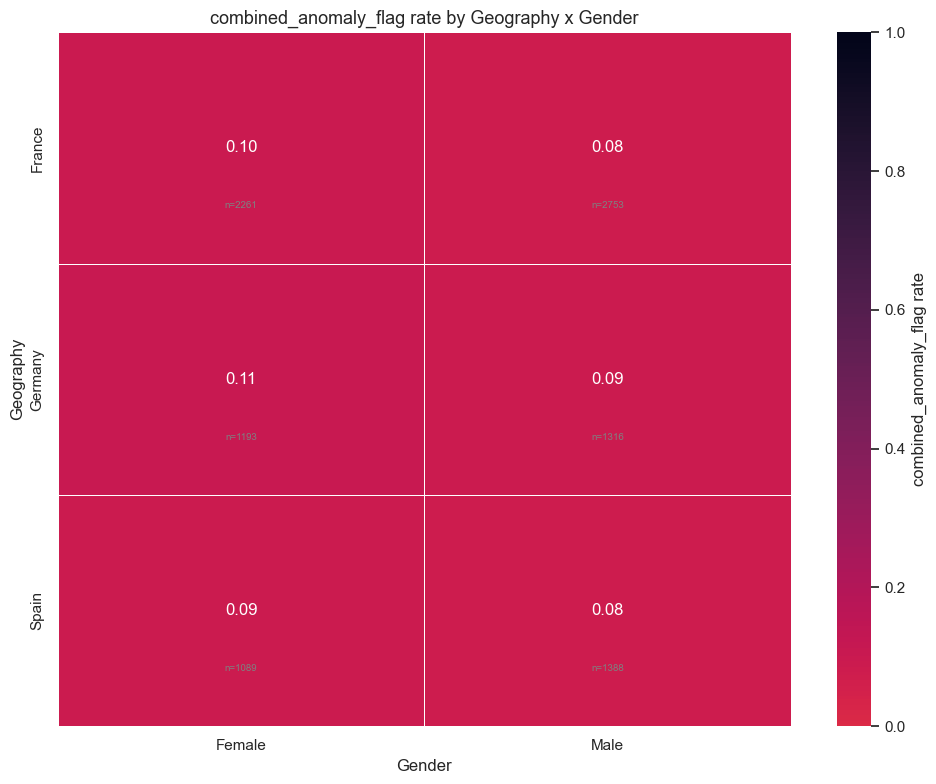


Geography x IsActiveMember anomaly interaction:


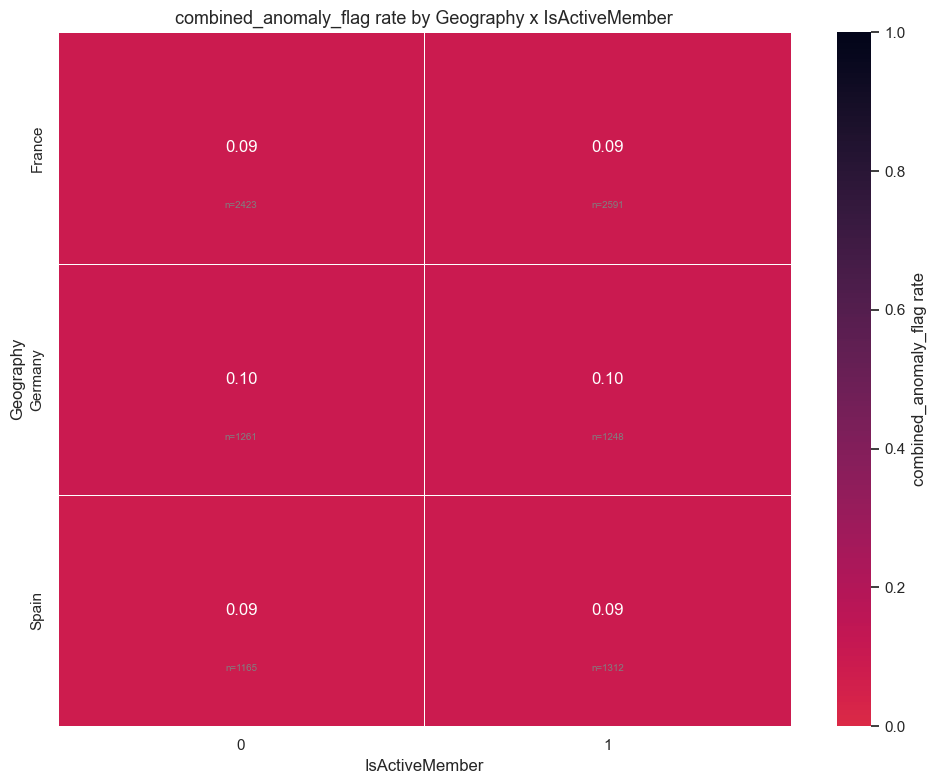


Geography x HasCrCard anomaly interaction:


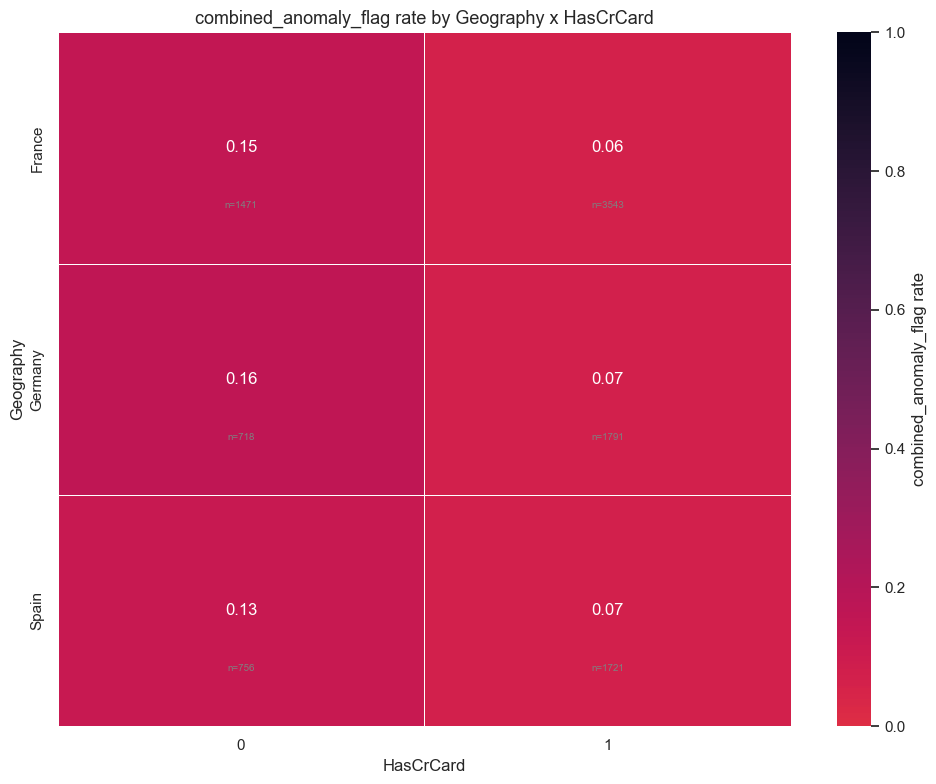


Gender x IsActiveMember anomaly interaction:


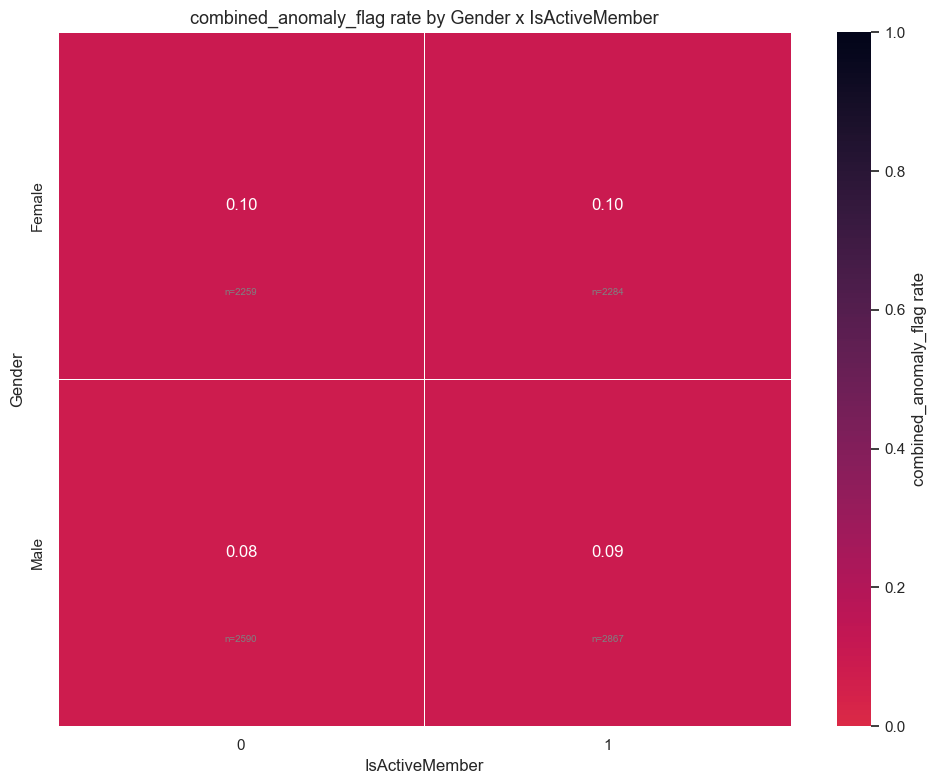


5. FEATURE STABILITY ACROSS SUBGROUPS
----------------------------------------

Distribution stability by Gender:


,Gender,mean_value,count,deviation,deviation_pct,feature,subgroup_col,overall_value
0,Female,4.942930e+03,4543,-57.570438,-1.151294,RowNumber,Gender,5.000500e+03
1,Male,5.048428e+03,5457,47.927891,0.958462,RowNumber,Gender,5.000500e+03
2,Female,1.569115e+07,4543,208.221927,0.001327,CustomerId,Gender,1.569094e+07
3,Male,1.569077e+07,5457,-173.346567,-0.001105,CustomerId,Gender,1.569094e+07
4,Female,6.508314e+02,4543,0.302589,0.046514,CreditScore,Gender,6.505288e+02
5,Male,6.502769e+02,5457,-0.251908,-0.038724,CreditScore,Gender,6.505288e+02
6,Female,3.923839e+01,4543,0.316589,0.813397,Age,Gender,3.892180e+01
7,Male,3.865824e+01,5457,-0.263563,-0.677160,Age,Gender,3.892180e+01
8,Female,4.966102e+00,4543,-0.046698,-0.931581,Tenure,Gender,5.012800e+00
9,Male,5.051677e+00,5457,0.038877,0.775550,Tenure,Gender,5.012800e+00



Distribution stability by Geography:


,Geography,mean_value,count,deviation,deviation_pct,feature,subgroup_col,overall_value
0,France,5.025229e+03,5014,24.728560,0.494522,RowNumber,Geography,5.000500e+03
1,Germany,5.000279e+03,2509,-0.221004,-0.004420,RowNumber,Geography,5.000500e+03
2,Spain,4.950668e+03,2477,-49.832257,-0.996545,RowNumber,Geography,5.000500e+03
3,France,1.569065e+07,5014,-290.455718,-0.001851,CustomerId,Geography,1.569094e+07
4,Germany,1.569056e+07,2509,-384.916550,-0.002453,CustomerId,Geography,1.569094e+07
5,Spain,1.569192e+07,2477,977.836333,0.006232,CustomerId,Geography,1.569094e+07
6,France,6.496683e+02,5014,-0.860471,-0.132273,CreditScore,Geography,6.505288e+02
7,Germany,6.514536e+02,2509,0.924767,0.142156,CreditScore,Geography,6.505288e+02
8,Spain,6.513339e+02,2477,0.805072,0.123756,CreditScore,Geography,6.505288e+02
9,France,3.851177e+01,5014,-0.410033,-1.053479,Age,Geography,3.892180e+01



Distribution stability by IsActiveMember:


...

,HasCrCard,mean_value,count,deviation,deviation_pct,feature,subgroup_col,overall_value
0,0,4.997825e+03,2945,-2.675212,-0.053499,RowNumber,HasCrCard,5.000500e+03
1,1,5.001617e+03,7055,1.116726,0.022332,RowNumber,HasCrCard,5.000500e+03
2,0,1.569250e+07,2945,1561.487306,0.009952,CustomerId,HasCrCard,1.569094e+07
3,1,1.569029e+07,7055,-651.818585,-0.004154,CustomerId,HasCrCard,1.569094e+07
4,0,6.513453e+02,2945,0.816531,0.125518,CreditScore,HasCrCard,6.505288e+02
5,1,6.501880e+02,7055,-0.340848,-0.052396,CreditScore,HasCrCard,6.505288e+02
6,0,3.911205e+01,2945,0.190254,0.488812,Age,HasCrCard,3.892180e+01
7,1,3.884238e+01,7055,-0.079419,-0.204047,Age,HasCrCard,3.892180e+01
8,0,4.911715e+00,2945,-0.101085,-2.016542,Tenure,HasCrCard,5.012800e+00
9,1,5.054996e+00,7055,0.042196,0.841774,Tenure,HasCrCard,5.012800e+00



6. RELATIONSHIP STABILITY ACROSS GROUPS
----------------------------------------


,subgroup_col,segment,feature,count,overall_spearman,subgroup_spearman,association_gap,abs_association_gap
0,IsActiveMember,0,Age,4849,0.323968,0.439329,0.115361,0.115361
1,IsActiveMember,1,Age,5151,0.323968,0.226879,-0.097089,0.097089
2,Geography,Spain,Age,2477,0.323968,0.253595,-0.070373,0.070373
3,Geography,Germany,Age,2509,0.323968,0.389268,0.065300,0.065300
4,Geography,Spain,Tenure,2477,-0.013978,-0.058037,-0.044059,0.044059
5,Geography,Germany,RowNumber,2509,-0.016571,0.018145,0.034716,0.034716
6,IsActiveMember,1,RowNumber,5151,-0.016571,0.010897,0.027468,0.027468
7,Geography,Spain,CustomerId,2477,-0.006264,-0.026558,-0.020294,0.020294
8,Gender,Male,Age,5457,0.323968,0.303722,-0.020246,0.020246
9,IsActiveMember,0,RowNumber,4849,-0.016571,-0.036796,-0.020224,0.020224



7. KEY INSIGHTS
----------------------------------------
Key findings:
  - Large variation in Exited rate across Geography: 16.2% to 32.4%.
  - Large variation in Exited rate across IsActiveMember: 14.3% to 26.9%.
  - Large variation in Exited rate across Age_Band: 7.5% to 50.6%.



,subgroup_col,segment,feature,count,overall_spearman,subgroup_spearman,association_gap,abs_association_gap
0,IsActiveMember,0,Age,4849,0.323968,0.439329,0.115361,0.115361
1,IsActiveMember,1,Age,5151,0.323968,0.226879,-0.097089,0.097089
2,Geography,Spain,Age,2477,0.323968,0.253595,-0.070373,0.070373
3,Geography,Germany,Age,2509,0.323968,0.389268,0.065300,0.065300
4,Geography,Spain,Tenure,2477,-0.013978,-0.058037,-0.044059,0.044059
5,Geography,Germany,RowNumber,2509,-0.016571,0.018145,0.034716,0.034716
6,IsActiveMember,1,RowNumber,5151,-0.016571,0.010897,0.027468,0.027468
7,Geography,Spain,CustomerId,2477,-0.006264,-0.026558,-0.020294,0.020294
8,Gender,Male,Age,5457,0.323968,0.303722,-0.020246,0.020246
9,IsActiveMember,0,RowNumber,4849,-0.016571,-0.036796,-0.020224,0.020224


In [10]:
subgroup_df = df_with_audit.copy()
if 'combined_anomaly_flag' not in subgroup_df.columns and 'anomaly_vote_count' in subgroup_df.columns:
    subgroup_df['combined_anomaly_flag'] = (subgroup_df['anomaly_vote_count'].fillna(0) > 0).astype(int)

subgroup_results = comprehensive_subgroup_analysis(
    subgroup_df,
    target_col=target_col,
    segmentation_cols=['Gender', 'Geography', 'IsActiveMember', 'HasCrCard'],
    anomaly_score_col='combined_anomaly_score' if 'combined_anomaly_score' in subgroup_df.columns else None,
    anomaly_flag_col='combined_anomaly_flag' if 'combined_anomaly_flag' in subgroup_df.columns else None,
    age_col='Age',
    min_support=50,
)

subgroup_results['relationship_stability'].head(10) if not subgroup_results['relationship_stability'].empty else 'No relationship instability rows found.'
